# Post-Hoc Reasoning Results Visualization

This notebook creates visualizations for parse rates and steering success rates across different alpha values.

In [29]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import pandas as pd

# Clear matplotlib font cache and rebuild it
plt.rcParams.update({'font.size': 10})
# fm._rebuild()

# Check if Lato is available
available_fonts = [f.name for f in fm.fontManager.ttflist]
lato_available = any('Lato' in font for font in available_fonts)
print(f"Lato font available: {lato_available}")
if lato_available:
    print("Available Lato variants:", [f for f in available_fonts if 'Lato' in f])

# Set style for cleaner plots
plt.style.use('default')  # Reset to default first
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 0.8

# Use Lato font with fallbacks - try different Lato variants
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Lato',                # Primary choice
    'Lato Regular',        # Explicit variant
    'Lato-Regular',        # Alternative naming
    'Helvetica Neue',      # macOS (very clean, similar to Lato)
    'Arial',               # Windows/Mac/Linux (clean and widely available)
    'Liberation Sans',     # Linux (open source, clean design)
    'DejaVu Sans',        # Cross-platform (matplotlib default)
    'sans-serif'          # Generic fallback
]

# Use normal font weight
plt.rcParams['font.weight'] = 'normal'

# Alternative method: try to load Lato directly if available
try:
    # Try to create a test figure to verify font loading
    fig, ax = plt.subplots(figsize=(1, 1))
    ax.text(0.5, 0.5, 'Test', fontfamily='Lato')
    current_font = ax.texts[0].get_fontfamily()
    plt.close(fig)
    print(f"Current font being used: {current_font}")
except Exception as e:
    print(f"Font loading test failed: {e}")
    print("Using fallback fonts")

Lato font available: True
Available Lato variants: ['Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato']
Current font being used: ['Lato']


In [30]:
# Configuration
CACHE_DIR = Path("darius_cache/experiments")
MODELS = [
    "google/gemma-2-2b-it",
    "google/gemma-2-9b-it",
    "Qwen/Qwen2.5-1.5b-Instruct", 
    "Qwen/Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
]
DATASETS = ["anachronisms", "logical_deduction", "social_chemistry", "sports_understanding"]

In [31]:
def load_steering_results(model_path, dataset):
    """Load all steering results for a given model and dataset."""
    results = defaultdict(list)
    
    # Try both cache directories
    for cache_name in ["darius_cache/experiments"]:
        cache_dir = Path(cache_name)
        if not cache_dir.exists():
            continue
            
        # Find the experiment directory
        model_dir = cache_dir / model_path.replace("/", "_") / dataset
        if not model_dir.exists():
            # Try without underscores in model name
            model_dir = cache_dir / model_path.replace("/", "-") / dataset
            if not model_dir.exists():
                continue
        
        # Find the split directory (assuming first one found)
        split_dirs = list(model_dir.glob("split_*"))
        if not split_dirs:
            continue
        
        split_dir = split_dirs[0]
        
        # Find the hash directory
        hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and len(d.name) > 10]
        if not hash_dirs:
            continue
        
        hash_dir = hash_dirs[0]
        steering_dir = hash_dir / "steering"
        
        if not steering_dir.exists():
            continue
        
        # Load all steering result files
        for file_path in steering_dir.glob("*.pkl"):
            # Parse filename to get alpha and direction
            filename = file_path.stem
            parts = filename.split("_")
            
            if "alpha" in filename:
                # Find alpha value
                alpha_idx = parts.index("alpha") + 1
                alpha = float(parts[alpha_idx])
                
                # For alpha=0, the suffix indicates the ORIGINAL answer
                # We need to assign to the OPPOSITE direction (the steering target)
                if alpha == 0:
                    if "yes" in filename:
                        # Original answer is yes, so this is yes→no steering
                        direction = "no"  # FIXED: was "yes"
                    elif "no" in filename:
                        # Original answer is no, so this is no→yes steering
                        direction = "yes"  # FIXED: was "no"
                    else:
                        continue  # Skip if direction unclear
                else:
                    # For non-zero alpha, determine by sign
                    # Positive alpha = no→yes steering (direction = "yes")
                    # Negative alpha = yes→no steering (direction = "no")
                    direction = "yes" if alpha > 0 else "no"
                
                # Load the results
                with open(file_path, "rb") as f:
                    data = pickle.load(f)
                    results[direction].append((abs(alpha), data))
        
        # If we found results, break (don't check other cache)
        if results:
            break
    
    return results

In [32]:
def calculate_metrics(steering_data):
    """Calculate no parse rate and steering success rate from steering results with confidence intervals."""
    if not steering_data:
        return 0.0, 0.0, 0.0, 0.0
    
    total = len(steering_data)
    valid_parses = sum(1 for item in steering_data if item.get('is_valid_parse', False))
    successes = sum(1 for item in steering_data if item.get('success', False))
    
    # No parse rate is 1 - parse rate
    no_parse_rate = 1 - (valid_parses / total) if total > 0 else 0.0
    # Success rate denominator is number of valid parses, not total
    success_rate = successes / valid_parses if valid_parses > 0 else 0.0
    
    # Calculate standard errors using binomial proportion formula
    # SE = sqrt(p * (1-p) / n)
    no_parse_se = np.sqrt(no_parse_rate * (1 - no_parse_rate) / total) if total > 0 else 0.0
    success_se = np.sqrt(success_rate * (1 - success_rate) / valid_parses) if valid_parses > 0 else 0.0
    
    # Convert to 95% confidence interval (1.96 * SE)
    no_parse_ci = 1.96 * no_parse_se
    success_ci = 1.96 * success_se
    
    # Ensure confidence intervals don't go below 0 or above 1
    # This is especially important for extreme rates near 0 or 1
    # The CI returned here is the half-width that will be added/subtracted from the rate
    # So we need to ensure rate - CI >= 0 and rate + CI <= 1
    success_ci = min(success_ci, success_rate, 1 - success_rate)
    no_parse_ci = min(no_parse_ci, no_parse_rate, 1 - no_parse_rate)
    
    return no_parse_rate, success_rate, no_parse_ci, success_ci

In [81]:
def create_dataset_plot(ax, yes_data, no_data, dataset, show_legend=False, show_ylabel=True):
    """Create a plot showing both steering directions for a dataset with a fixed x-axis 0–20 (step 2)."""
    # Colors matching the reference image: Teal for "No to Yes", Red for "Yes to No"
    no_to_yes_color = '#7AADA9'
    yes_to_no_color = '#B0E0E6'

    # Collect results by alpha for quick lookup
    yes_direction_results = {}
    no_direction_results = {}

    if yes_data:
        for alpha, data in yes_data:
            valid_parses = sum(1 for item in data if item.get('is_valid_parse', False))
            if valid_parses >= 20:
                no_parse_rate, success_rate, _, success_ci = calculate_metrics(data)
                yes_direction_results[alpha] = {
                    'success_rate': success_rate,
                    'success_ci': success_ci,
                    'no_parse_rate': no_parse_rate,
                }

    if no_data:
        for alpha, data in no_data:
            valid_parses = sum(1 for item in data if item.get('is_valid_parse', False))
            if valid_parses >= 20:
                no_parse_rate, success_rate, _, success_ci = calculate_metrics(data)
                no_direction_results[alpha] = {
                    'success_rate': success_rate,
                    'success_ci': success_ci,
                    'no_parse_rate': no_parse_rate,
                }

    # If absolutely no data, return early
    if not yes_direction_results and not no_direction_results:
        return

    # Fixed alpha grid from 0 to 20 in steps of 2
    fixed_alphas = np.arange(0, 21, 2)

    # Prepare data arrays aligned to the fixed alpha grid
    yes_to_no_rates = []
    yes_to_no_errors = []
    no_to_yes_rates = []
    no_to_yes_errors = []

    # Prepare arrays for unparsed rates (blue 'x' markers)
    yes_to_no_unparsed = []
    no_to_yes_unparsed = []

    for alpha in fixed_alphas:
        if alpha in yes_direction_results:
            yes_to_no_rates.append(yes_direction_results[alpha]['success_rate'])
            yes_to_no_errors.append(yes_direction_results[alpha]['success_ci'])
            yes_to_no_unparsed.append(yes_direction_results[alpha]['no_parse_rate'])
        else:
            yes_to_no_rates.append(np.nan)
            yes_to_no_errors.append(0)
            # Missing alpha implies 100% unparsed for this series
            yes_to_no_unparsed.append(1.0)

        if alpha in no_direction_results:
            no_to_yes_rates.append(no_direction_results[alpha]['success_rate'])
            no_to_yes_errors.append(no_direction_results[alpha]['success_ci'])
            no_to_yes_unparsed.append(no_direction_results[alpha]['no_parse_rate'])
        else:
            no_to_yes_rates.append(np.nan)
            no_to_yes_errors.append(0)
            # Missing alpha implies 100% unparsed for this series
            no_to_yes_unparsed.append(1.0)

    # Bar positions and width (numeric x-axis)
    x = fixed_alphas.astype(float)
    bar_width = 0.5

    ax.bar(x - bar_width / 2, yes_to_no_rates, bar_width,
           yerr=yes_to_no_errors, capsize=0,
           color=yes_to_no_color, alpha=1.0,
           edgecolor='none',
           error_kw={'linewidth': 1.5, 'elinewidth': 1.5, 'color': 'black'},
           label='Yes to No')

    ax.bar(x + bar_width / 2, no_to_yes_rates, bar_width,
           yerr=no_to_yes_errors, capsize=0,
           color=no_to_yes_color, alpha=1.0,
           edgecolor='none',
           error_kw={'linewidth': 1.5, 'elinewidth': 1.5, 'color': 'black'},
           label='No to Yes')

    # Overlay unparsed rates as blue 'x' markers at bar centers (no connecting lines)
    marker_color = '#D04545'  # red x markers to match previous red    # Yes→No markers
    ax.scatter(x - bar_width / 2, yes_to_no_unparsed, marker='x', s=50, color=marker_color, zorder=5)
    # No→Yes markers
    ax.scatter(x + bar_width / 2, no_to_yes_unparsed, marker='x', s=50, color=marker_color, zorder=5)

    # Title formatting
    dataset_display = dataset.replace('_', ' ').title()
    if dataset_display == 'Quora Question Pairs':
        dataset_display = 'Quora Question Pairs'
    elif dataset_display == 'Sports Understanding':
        dataset_display = 'Sports Understanding'
    elif dataset_display == 'Social Chemistry':
        dataset_display = 'Social Chemistry'
    elif dataset_display == 'Logical Deduction':
        dataset_display = 'Logical Deduction'

    ax.set_title(f'{dataset_display}', fontsize=16, fontweight='normal', color='black', pad=15)

    # Fixed x-axis 0..20 with ticks every 2, with slight padding so 20 tick isn't at the border (and bars at 0 aren't clipped)
    ax.set_xlim(-0.9, 20.9)
    ax.set_xticks(np.arange(0, 21, 2))
    ax.set_xticklabels([str(a) for a in range(0, 21, 2)], fontsize=13, color='black')

    # Legend
    if show_legend:
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = [
            Patch(facecolor=yes_to_no_color, alpha=0.8, label='Yes to No'),
            Patch(facecolor=no_to_yes_color, alpha=0.8, label='No to Yes'),
            Line2D([0], [0], marker='x', color='w', label='Unparsed Rate',
                   markerfacecolor='w', markeredgecolor=marker_color, markersize=8, linestyle='None')
        ]
        ax.legend(handles=legend_elements, loc='upper left', frameon=True,
                  fontsize=10, title='Condition', title_fontsize=10)

    # Y-axis formatting
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    if show_ylabel:
        ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.1, 0.2)], fontsize=13, color='black')
    else:
        ax.set_yticklabels([])

    # Grid and spines
    ax.grid(True, axis='y', alpha=0.6, linestyle='--', linewidth=1.2, color='#888888')
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')

    ax.spines['top'].set_linewidth(1.0)
    ax.spines['right'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

def create_model_grid(model, all_model_results):
    """Create a 2x2 grid of plots for a single model showing all datasets with yes/no directions."""
    # Check if we have any data for this model
    if not all_model_results:
        return None
    
    # Create figure with 2x2 subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 9))
    fig.patch.set_facecolor('white')
    
    # Format model name
    short = model.split('/')[-1]
    if short == 'gemma-2-2b-it':
        model_display = 'Gemma 2 2B-it'
    elif short == 'gemma-2-9b-it':
        model_display = 'Gemma 2 9B-it'
    else:
        model_display = short.replace('-', ' ').title()
    fig.suptitle(f'Answer Change Frequency by Steering Coefficient\n{model_display}', 
                 fontsize=18, fontweight='normal', color='black', y=0.95)
    
    # Define the axes for the four datasets
    axes = [ax1, ax2, ax3, ax4]
    
    plot_count = 0
    for i, dataset in enumerate(DATASETS):
        ax = axes[i]
        
        # Determine if this is a leftmost plot (first column): positions 0 and 2
        is_leftmost = (i == 0 or i == 2)
        
        if dataset in all_model_results:
            # Get both yes and no direction data
            yes_data = all_model_results[dataset].get("yes", [])
            no_data = all_model_results[dataset].get("no", [])
            
            if yes_data or no_data:
                # Sort data by alpha value
                if yes_data:
                    yes_data.sort(key=lambda x: x[0])
                if no_data:
                    no_data.sort(key=lambda x: x[0])
                
                # Create the plot (show legend only on first plot, y-labels only on leftmost plots)
                create_dataset_plot(ax, yes_data, no_data, dataset, 
                                  show_legend=(plot_count == 0),
                                  show_ylabel=is_leftmost)
                plot_count += 1
            else:
                # Dataset found but no data in either direction
                ax.text(0.5, 0.5, f'No data for\n{dataset.replace("_", " ")}', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, color='gray')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.set_xticks([])
                ax.set_yticks([])
        else:
            # No data for this dataset at all
            ax.text(0.5, 0.5, f'No data for\n{dataset.replace("_", " ")}', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, color='gray')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks([])
            ax.set_yticks([])
    
    # Add common axis labels matching the reference image
    fig.text(0.5, 0.04, 'Steering Coefficient', ha='center', fontsize=16, fontweight='normal', color='black')
    fig.text(0.04, 0.5, 'Change Answer Rate', va='center', rotation='vertical', fontsize=16, fontweight='normal', color='black')
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08, left=0.08, top=0.88)
    return fig

def create_bar_plots(model, dataset, direction_data, direction="yes"):
    """Legacy function for backward compatibility - creates individual plots showing single direction."""
    if not direction_data:
        return None
    
    # Create figure with white background
    fig, ax = plt.subplots(figsize=(10, 1))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Use the new function but only pass data for the requested direction
    if direction == "yes":
        create_dataset_plot(ax, direction_data, [], dataset, show_legend=True)
    else:
        create_dataset_plot(ax, [], direction_data, dataset, show_legend=True)
    
    # Format model name
    short = model.split('/')[-1]
    if short == 'gemma-2-2b-it':
        model_display = 'Gemma 2 2B-it'
    elif short == 'gemma-2-9b-it':
        model_display = 'Gemma 2 9B-it'
    else:
        model_display = short.replace('-', ' ')
    
    # Add model name to title
    ax.set_title(f'{model_display}\n{dataset.replace("_", " ")}: {direction}', 
                 fontsize=16, fontweight='normal', color='black', pad=20)
    
    # Customize axis labels
    ax.set_xlabel('α', fontsize=14, fontweight='normal', color='black')
    ax.set_ylabel('Success Rate', fontsize=14, fontweight='normal', color='black')
    
    plt.tight_layout()
    return fig

In [ ]:
# Create vertically stacked steering plots per model
print('\nGenerating stacked steering plots per model...')
stacked_steer_figs = []
for model in MODELS:
    # Collect all results for this model across all datasets
    all_model_results = {}
    for dataset in DATASETS:
        res = load_steering_results(model, dataset)
        if res:
            all_model_results[dataset] = res
    if not all_model_results:
        continue

    fig = plt.figure(figsize=(14, 18))
    axes = [plt.subplot(len(DATASETS), 1, i + 1) for i in range(len(DATASETS))]

    # Model title formatting consistent with grid
    short = model.split('/')[-1]
    if short == 'gemma-2-2b-it':
        model_display = 'Gemma 2 2B-it'
    elif short == 'gemma-2-9b-it':
        model_display = 'Gemma 2 9B-it'
    else:
        model_display = short.replace('-', ' ').title()
    fig.suptitle(f'Answer Change Frequency by Steering Coefficient\n{model_display}',
                 fontsize=18, fontweight='normal', color='black', y=0.98)

    for i, dataset in enumerate(DATASETS):
        ax = axes[i]
        yes_data = all_model_results.get(dataset, {}).get('yes', [])
        no_data = all_model_results.get(dataset, {}).get('no', [])
        if yes_data or no_data:
            if yes_data:
                yes_data.sort(key=lambda x: x[0])
            if no_data:
                no_data.sort(key=lambda x: x[0])
            create_dataset_plot(ax, yes_data, no_data, dataset, show_legend=(i == 0), show_ylabel=True)
        else:
            ax.text(0.5, 0.5, f'No data for\n{dataset.replace("_", " ")}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=12, color='gray')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks([])
            ax.set_yticks([])

    axes[-1].set_xlabel('Steering Coefficient', fontsize=16, fontweight='normal', color='black')
    fig.text(0.04, 0.5, 'Change Answer Rate', va='center', rotation='vertical', fontsize=16, fontweight='normal', color='black')

    plt.tight_layout(rect=(0.06, 0.04, 1.0, 0.95))
    stacked_steer_figs.append((model, fig))
    plt.show()

# Save the stacked figures
outdir = Path('visualizations')
outdir.mkdir(exist_ok=True)
for model, fig in stacked_steer_figs:
    path = outdir / f"{model.replace('/', '_')}_steering_stacked.png"
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved stacked steering figure: {path}")



Processing model: google/gemma-2-2b-it...
  Found data for anachronisms
    Created individual yes direction plot
    Created individual no direction plot
  Found data for logical_deduction
    Created individual yes direction plot
    Created individual no direction plot
  Found data for social_chemistry
    Created individual yes direction plot
    Created individual no direction plot


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) La

  Found data for sports_understanding
    Created individual yes direction plot


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


    Created individual no direction plot


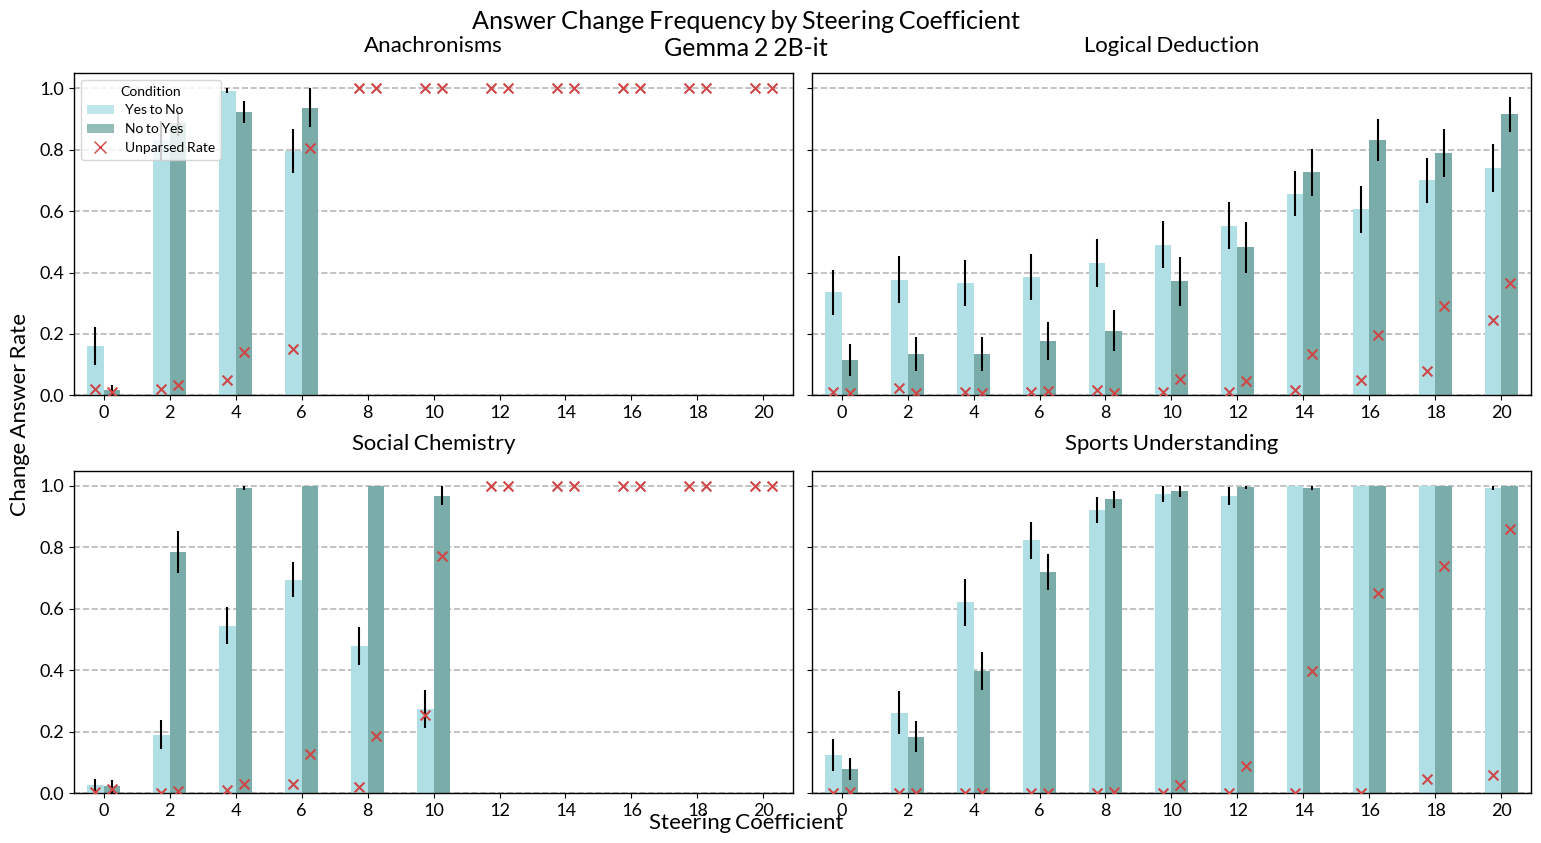

  Created grid visualization with 4 datasets

Processing model: google/gemma-2-9b-it...
  Found data for anachronisms
    Created individual yes direction plot
    Created individual no direction plot
  Found data for logical_deduction
    Created individual yes direction plot
    Created individual no direction plot
  Found data for social_chemistry
    Created individual yes direction plot
    Created individual no direction plot
  Found data for sports_understanding


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) La

    Created individual yes direction plot
    Created individual no direction plot


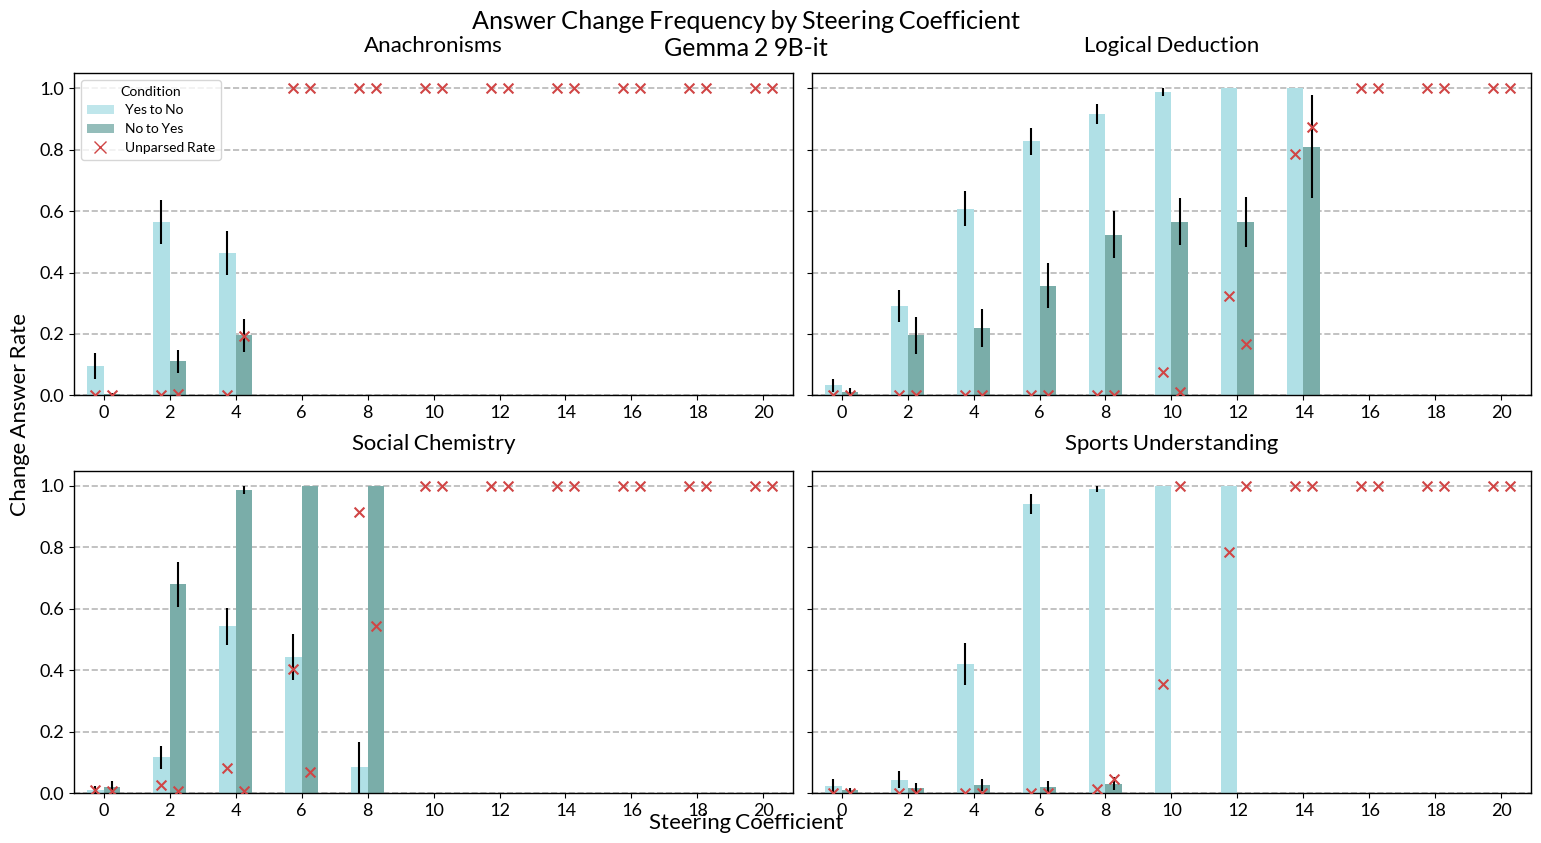

  Created grid visualization with 4 datasets

Processing model: Qwen/Qwen2.5-1.5b-Instruct...
  Found data for anachronisms
    Created individual yes direction plot


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


    Created individual no direction plot
  Found data for logical_deduction


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) La

    Created individual yes direction plot
    Created individual no direction plot
  Found data for social_chemistry
    Created individual yes direction plot
    Created individual no direction plot
  Found data for sports_understanding
    Created individual yes direction plot
    Created individual no direction plot


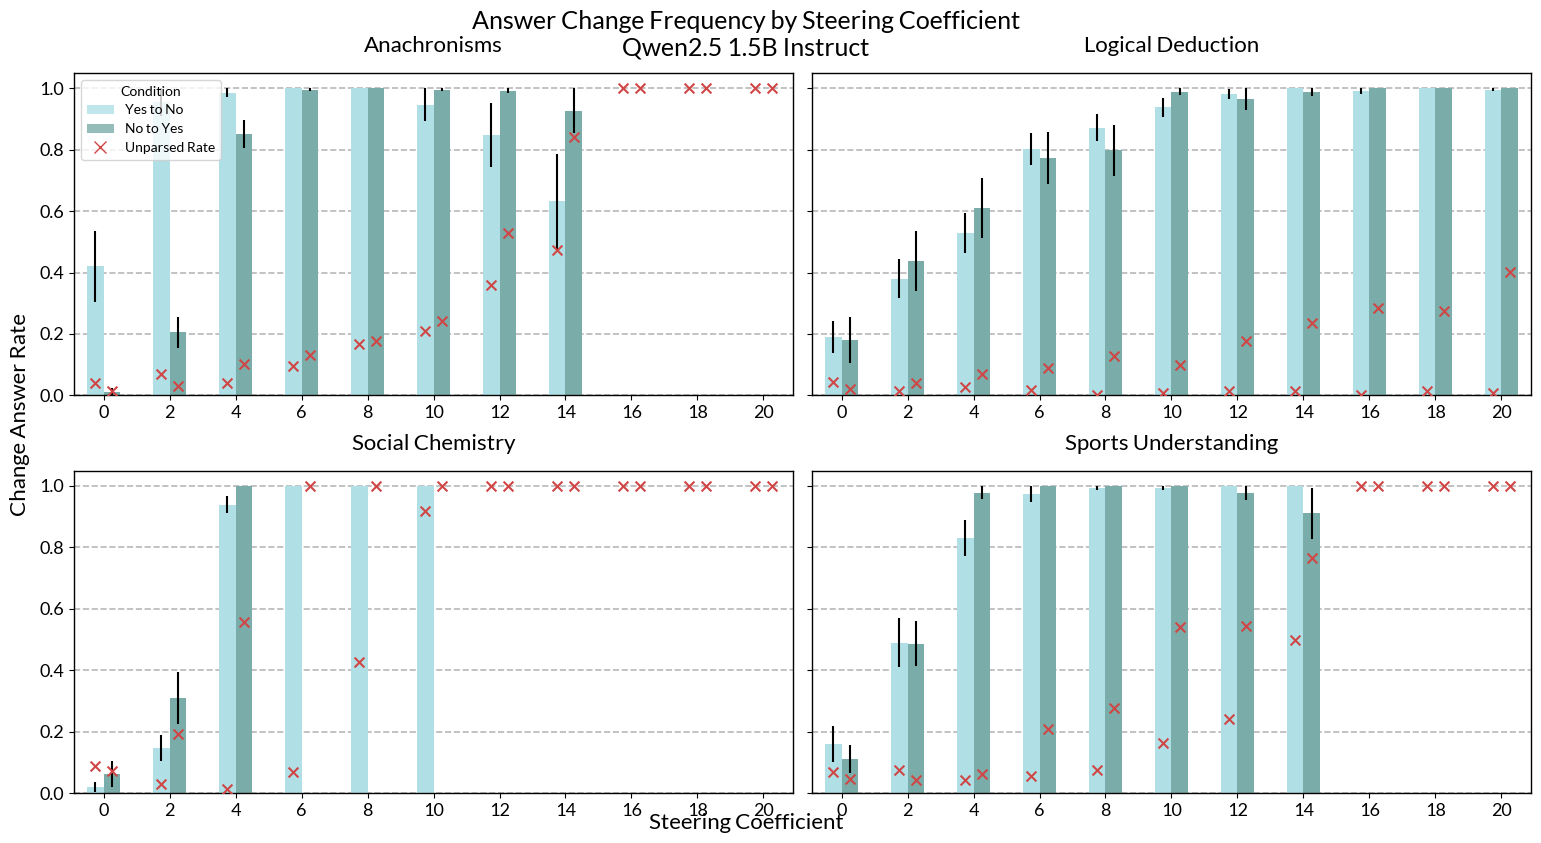

  Created grid visualization with 4 datasets

Processing model: Qwen/Qwen2.5-3B-Instruct...
  Found data for anachronisms
    Created individual yes direction plot
    Created individual no direction plot
  Found data for logical_deduction
    Created individual yes direction plot
    Created individual no direction plot
  Found data for social_chemistry


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) La

    Created individual yes direction plot
    Created individual no direction plot
  Found data for sports_understanding
    Created individual yes direction plot
    Created individual no direction plot


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


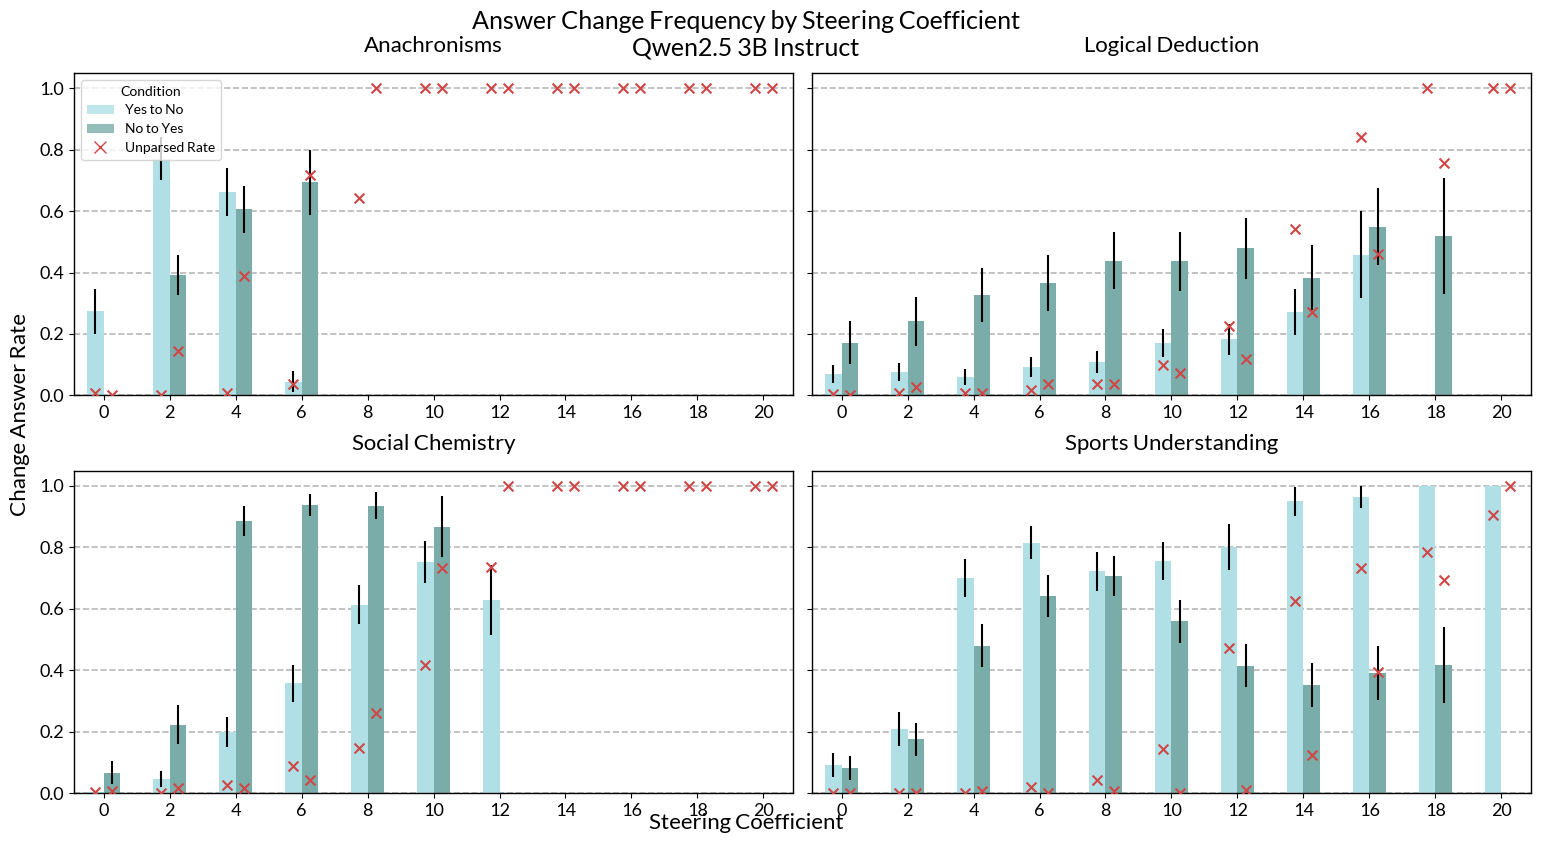

  Created grid visualization with 4 datasets

Processing model: Qwen/Qwen2.5-7B-Instruct...
  Found data for anachronisms
    Created individual yes direction plot
    Created individual no direction plot
  Found data for logical_deduction
    Created individual yes direction plot
    Created individual no direction plot
  Found data for social_chemistry


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) La

    Created individual yes direction plot
    Created individual no direction plot
  Found data for sports_understanding
    Created individual yes direction plot
    Created individual no direction plot


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2491342863.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


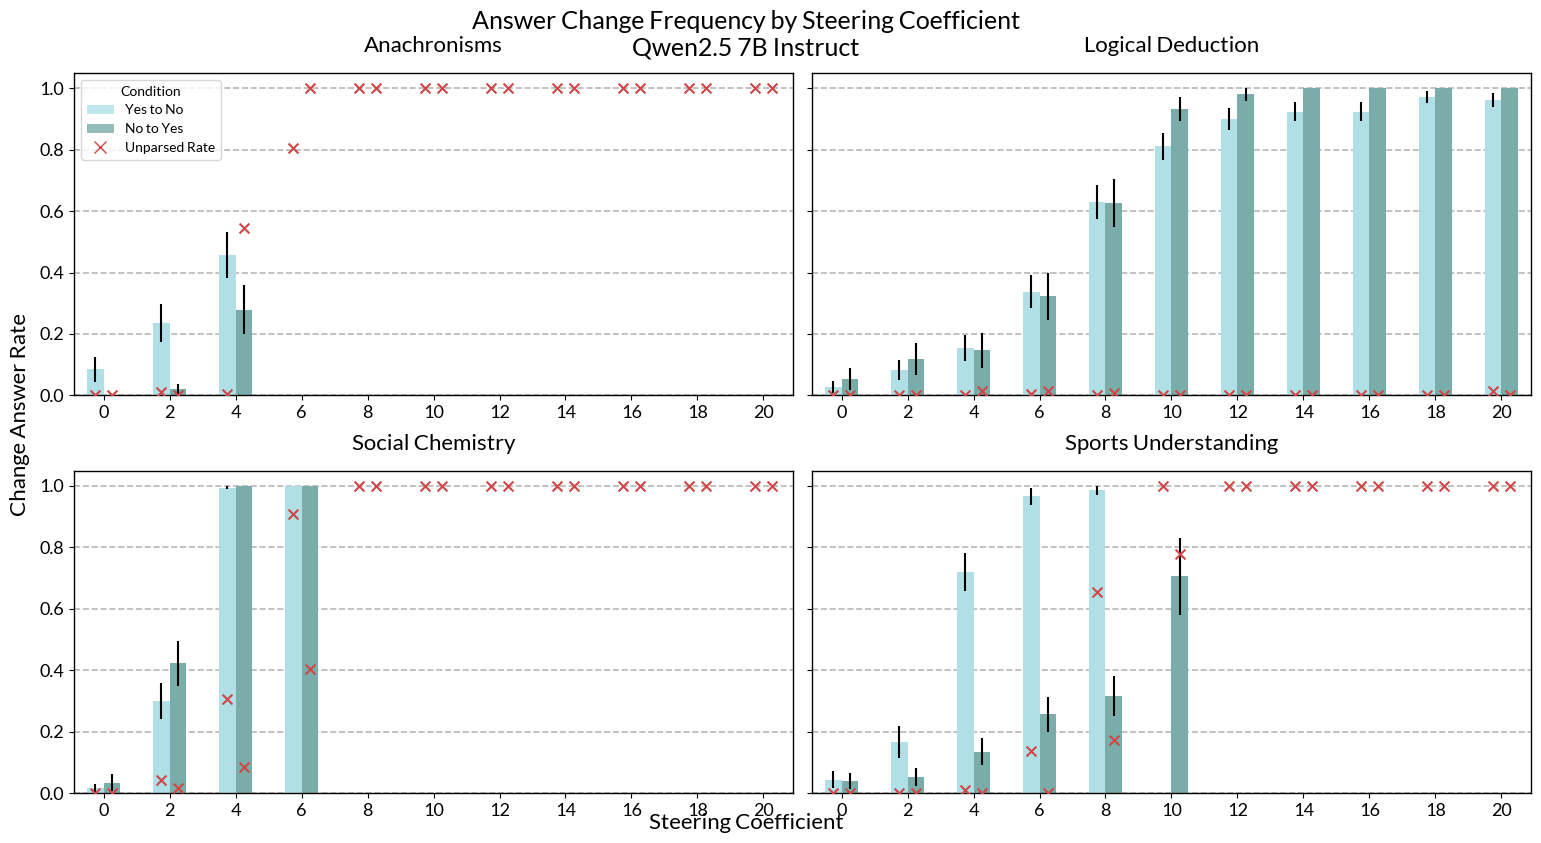

  Created grid visualization with 4 datasets

Processing model: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B...
  No steering results found for anachronisms
  No steering results found for logical_deduction
  No steering results found for social_chemistry
  No steering results found for sports_understanding
  No data found for any dataset

Processing model: deepseek-ai/DeepSeek-R1-Distill-Qwen-7B...
  No steering results found for anachronisms
  No steering results found for logical_deduction
  No steering results found for social_chemistry
  No steering results found for sports_understanding
  No data found for any dataset

Created 5 grid visualizations and 40 individual plots


In [82]:
# Generate side-by-side visualizations for each model
all_grid_figures = []
all_individual_figures = []  # Keep individual figures for backward compatibility

for model in MODELS:
    print(f"\nProcessing model: {model}...")
    
    # Collect all results for this model across all datasets
    all_model_results = {}
    has_any_data = False
    
    for dataset in DATASETS:
        results = load_steering_results(model, dataset)
        
        if results:
            all_model_results[dataset] = results
            has_any_data = True
            print(f"  Found data for {dataset}")
            
            # Also create individual plots for backward compatibility
            for direction in ["yes", "no"]:
                if direction in results:
                    fig = create_bar_plots(model, dataset, results[direction], direction)
                    if fig:
                        all_individual_figures.append((model, dataset, direction, fig))
                        # Don't show individual plots automatically
                        plt.close(fig)  # Close to save memory
                        print(f"    Created individual {direction} direction plot")
        else:
            print(f"  No steering results found for {dataset}")
    
    # Create the side-by-side grid figure for this model
    if has_any_data:
        grid_fig = create_model_grid(model, all_model_results)
        if grid_fig:
            all_grid_figures.append((model, grid_fig))
            plt.show()
            print(f"  Created grid visualization with {len([d for d in DATASETS if d in all_model_results])} datasets")
    else:
        print(f"  No data found for any dataset")

print(f"\nCreated {len(all_grid_figures)} grid visualizations and {len(all_individual_figures)} individual plots")

# For backward compatibility, keep reference to individual figures
all_figures = all_individual_figures

In [83]:
# Save all figures to files
output_dir = Path("visualizations")
output_dir.mkdir(exist_ok=True)

# Save grid figures (the main new visualizations)
print("Saving grid visualizations...")
for model, grid_fig in all_grid_figures:
    filename = f"{model.replace('/', '_')}_grid.png"
    filepath = output_dir / filename
    grid_fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved grid: {filepath}")

# Save individual figures (for backward compatibility)
print("\nSaving individual plots...")
for model, dataset, direction, fig in all_individual_figures:
    filename = f"{model.replace('/', '_')}_{dataset}_{direction}.png"
    filepath = output_dir / filename
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved individual: {filepath}")

print(f"\nTotal files saved: {len(all_grid_figures)} grid visualizations + {len(all_individual_figures)} individual plots")

Saving grid visualizations...
Saved grid: visualizations/google_gemma-2-2b-it_grid.png
Saved grid: visualizations/google_gemma-2-9b-it_grid.png
Saved grid: visualizations/Qwen_Qwen2.5-1.5b-Instruct_grid.png
Saved grid: visualizations/Qwen_Qwen2.5-3B-Instruct_grid.png
Saved grid: visualizations/Qwen_Qwen2.5-7B-Instruct_grid.png

Saving individual plots...
Saved individual: visualizations/google_gemma-2-2b-it_anachronisms_yes.png
Saved individual: visualizations/google_gemma-2-2b-it_anachronisms_no.png
Saved individual: visualizations/google_gemma-2-2b-it_logical_deduction_yes.png


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/273593967.py:18: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Lato.
  fig.savefig(filepath, dpi=300, bbox_inches='tight')


Saved individual: visualizations/google_gemma-2-2b-it_logical_deduction_no.png
Saved individual: visualizations/google_gemma-2-2b-it_social_chemistry_yes.png
Saved individual: visualizations/google_gemma-2-2b-it_social_chemistry_no.png
Saved individual: visualizations/google_gemma-2-2b-it_sports_understanding_yes.png
Saved individual: visualizations/google_gemma-2-2b-it_sports_understanding_no.png
Saved individual: visualizations/google_gemma-2-9b-it_anachronisms_yes.png
Saved individual: visualizations/google_gemma-2-9b-it_anachronisms_no.png
Saved individual: visualizations/google_gemma-2-9b-it_logical_deduction_yes.png
Saved individual: visualizations/google_gemma-2-9b-it_logical_deduction_no.png
Saved individual: visualizations/google_gemma-2-9b-it_social_chemistry_yes.png
Saved individual: visualizations/google_gemma-2-9b-it_social_chemistry_no.png
Saved individual: visualizations/google_gemma-2-9b-it_sports_understanding_yes.png
Saved individual: visualizations/google_gemma-2-9b-

In [84]:
# Create summary statistics
summary_data = []

for model in MODELS:
    for dataset in DATASETS:
        results = load_steering_results(model, dataset)
        
        if results:
            for direction in ["yes", "no"]:
                if direction in results:
                    for alpha, data in results[direction]:
                        no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
                        summary_data.append({
                            'Model': model.split('/')[-1],
                            'Dataset': dataset,
                            'Direction': direction,
                            'Alpha': alpha,
                            'No Parse Rate': no_parse_rate,
                            'Success Rate': success_rate,
                            'No Parse CI': no_parse_ci,
                            'Success CI': success_ci,
                            'N': len(data)
                        })

# Create DataFrame and display summary
if summary_data:
    df = pd.DataFrame(summary_data)
    print("\nSummary Statistics:")
    print(df.head(50))
    # print(df.groupby(['Model', 'Dataset', 'Direction'])[['No Parse Rate', 'Success Rate']].agg(['mean', 'std', 'max']))


Summary Statistics:
            Model            Dataset Direction  Alpha  No Parse Rate  \
0   gemma-2-2b-it       anachronisms       yes   20.0       1.000000   
1   gemma-2-2b-it       anachronisms       yes   16.0       1.000000   
2   gemma-2-2b-it       anachronisms       yes    0.0       0.021583   
3   gemma-2-2b-it       anachronisms       yes   18.0       1.000000   
4   gemma-2-2b-it       anachronisms       yes    2.0       0.021583   
5   gemma-2-2b-it       anachronisms       yes   14.0       1.000000   
6   gemma-2-2b-it       anachronisms       yes   10.0       1.000000   
7   gemma-2-2b-it       anachronisms       yes    6.0       0.151079   
8   gemma-2-2b-it       anachronisms       yes    4.0       0.050360   
9   gemma-2-2b-it       anachronisms       yes   12.0       1.000000   
10  gemma-2-2b-it       anachronisms       yes    8.0       0.906475   
11  gemma-2-2b-it       anachronisms        no   18.0       1.000000   
12  gemma-2-2b-it       anachronisms       

# Probe AUC Visualization Section

In [37]:
def load_auc_scores(model_path, dataset):
    """Load AUC scores for a given model and dataset."""
    # Find the experiment directory
    model_dir = CACHE_DIR / model_path.replace("/", "_") / dataset
    if not model_dir.exists():
        return None
    
    # Find the split directory
    split_dirs = list(model_dir.glob("split_*"))
    if not split_dirs:
        return None
    
    split_dir = split_dirs[0]
    
    # Find the hash directory
    hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and d.name not in ["data", "metadata", "probes", "steering"]]
    if not hash_dirs:
        return None
    
    hash_dir = hash_dirs[0]
    auc_file = hash_dir / "probes" / "auc_scores.json"
    
    if not auc_file.exists():
        return None
    
    with open(auc_file, "r") as f:
        return json.load(f)

In [38]:
def load_generation_accuracy(model_path, dataset):
    """Load generation data and calculate train/test accuracy."""
    accuracies = {'train': None, 'test': None}
    
    # Try both cache directories
    for cache_name in ["darius_cache/experiments"]:
        cache_dir = Path(cache_name)
        if not cache_dir.exists():
            continue
            
        # Find the experiment directory
        model_dir = cache_dir / model_path.replace("/", "_") / dataset
        if not model_dir.exists():
            # Try without underscores in model name
            model_dir = cache_dir / model_path.replace("/", "-") / dataset
            if not model_dir.exists():
                continue
        
        # Find the split directory
        split_dirs = list(model_dir.glob("split_*"))
        if not split_dirs:
            continue
        
        split_dir = split_dirs[0]
        
        # Find the hash directory
        hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and len(d.name) > 10]
        if not hash_dirs:
            continue
        
        hash_dir = hash_dirs[0]
        data_dir = hash_dir / "data"
        
        # Load train and test generations
        for split in ['train', 'test']:
            gen_file = data_dir / f"{split}_generations.pkl"
            if gen_file.exists():
                with open(gen_file, 'rb') as f:
                    generations = pickle.load(f)
                    
                # Calculate accuracy
                if isinstance(generations, list) and len(generations) > 0:
                    correct = 0
                    total = 0
                    
                    for gen in generations:
                        if isinstance(gen, dict):
                            # Check if prediction matches correct answer
                            if 'pred_letter' in gen and 'correct_letter' in gen:
                                if gen['pred_letter'] == gen['correct_letter']:
                                    correct += 1
                                total += 1
                            elif 'pred_answer' in gen and 'correct_answer' in gen:
                                if gen['pred_answer'] == gen['correct_answer']:
                                    correct += 1
                                total += 1
                    
                    if total > 0:
                        accuracies[split] = round(correct / total * 100, 1)
        
        # If we found data, break
        if accuracies['train'] is not None or accuracies['test'] is not None:
            break
    
    return accuracies

In [39]:
# Collect all AUC data
auc_data = []

for model in MODELS:
    for dataset in DATASETS:
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores:
            # AUC scores are stored as a list of floats (one per layer)
            if isinstance(auc_scores, list) and len(auc_scores) > 0:
                # Find best AUC and its layer index
                best_auc = max(auc_scores)
                best_layer = auc_scores.index(best_auc)
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })
            elif isinstance(auc_scores, dict):
                # Handle dictionary format if it exists
                if 'best_auc' in auc_scores:
                    best_auc = auc_scores['best_auc']
                    best_layer = auc_scores.get('best_layer', 'Unknown')
                else:
                    # Find best AUC from layer scores
                    layer_scores = {k: v for k, v in auc_scores.items() if k.startswith('layer_')}
                    if layer_scores:
                        best_layer = max(layer_scores, key=layer_scores.get)
                        best_auc = layer_scores[best_layer]
                        best_layer = best_layer.replace('layer_', '')
                    else:
                        continue
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })

# Create DataFrame
auc_df = pd.DataFrame(auc_data)
print(f"Found AUC data for {len(auc_df)} model-dataset combinations")

Found AUC data for 20 model-dataset combinations


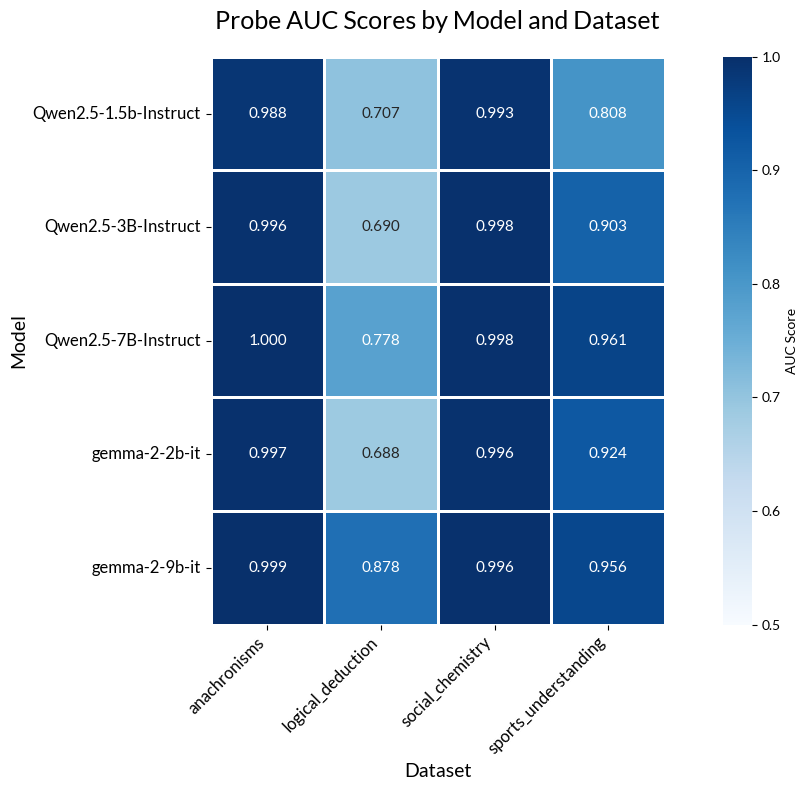

Saved AUC heatmap to visualizations/auc_heatmap.png


<Figure size 640x480 with 0 Axes>

In [40]:
# Create a heatmap of AUC scores
if not auc_df.empty:
    # Pivot the data for heatmap
    pivot_df = auc_df.pivot(index='Model_Short', columns='Dataset', values='Best_AUC')
    
    # Create figure with white background - BACK TO ORIGINAL SIZE
    plt.figure(figsize=(12, 8))  # Back to original
    fig = plt.gcf()
    fig.patch.set_facecolor('white')
    
    # Create heatmap with a better color scheme
    sns.heatmap(pivot_df, 
                annot=True, 
                fmt='.3f', 
                cmap='Blues',  # Use blues to match the bar charts
                vmin=0.5, 
                vmax=1.0,
                cbar_kws={'label': 'AUC Score'},
                square=True,
                linewidths=1,
                linecolor='white',
                annot_kws={'fontsize': 11, 'fontweight': 'normal'})  # Back to original
    
    plt.title('Probe AUC Scores by Model and Dataset', 
              fontsize=18, fontweight='normal', pad=20, color='black')  # Back to original
    plt.xlabel('Dataset', fontsize=14, fontweight='normal', color='black')  # Back to original
    plt.ylabel('Model', fontsize=14, fontweight='normal', color='black')  # Back to original
    plt.xticks(rotation=45, ha='right', fontsize=12, color='black')  # Back to original
    plt.yticks(rotation=0, fontsize=12, color='black')  # Back to original
    
    # Remove the default box around the plot
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Save the heatmap
    plt.savefig('visualizations/auc_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved AUC heatmap to visualizations/auc_heatmap.png")

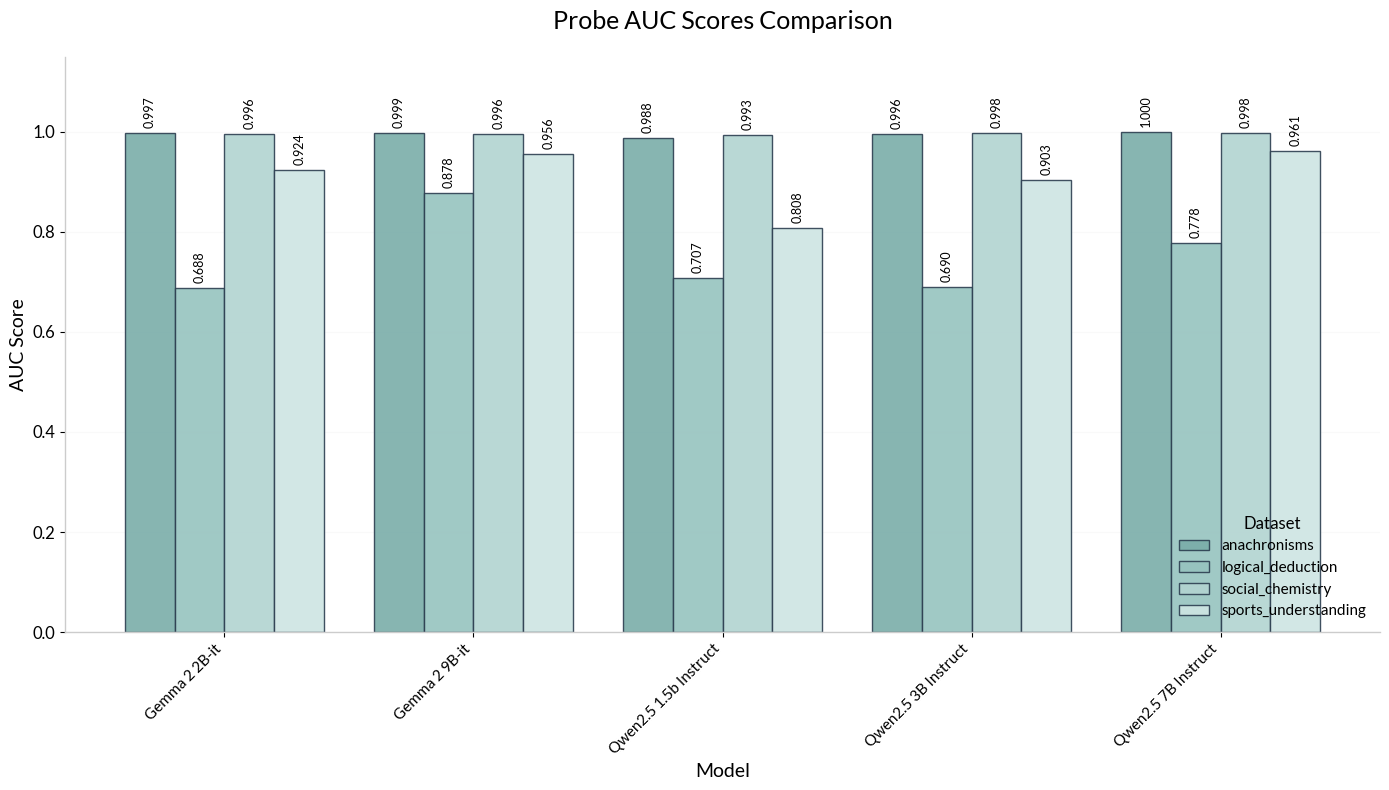

Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png


<Figure size 640x480 with 0 Axes>

In [41]:
# Create bar chart comparing models across datasets
if not auc_df.empty:
    fig, ax = plt.subplots(figsize=(14, 8))  # Back to original
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Get unique models and datasets
    models = auc_df['Model_Short'].unique()
    datasets = auc_df['Dataset'].unique()
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.2
    offsets = np.linspace(-width*1.5, width*1.5, len(datasets))
    
    # Color palette - variations of the new blue (122, 173, 169)
    colors = ['#7AADA9', '#96C3BF', '#B2D4D1', '#CEE5E3']
    
    # Create bars for each dataset
    for i, dataset in enumerate(datasets):
        dataset_data = auc_df[auc_df['Dataset'] == dataset]
        values = []
        for model in models:
            model_data = dataset_data[dataset_data['Model_Short'] == model]
            if not model_data.empty:
                values.append(model_data['Best_AUC'].iloc[0])
            else:
                values.append(0)  # Missing data
        
        bars = ax.bar(x + offsets[i], values, width, 
                      label=dataset, alpha=0.9,  # Almost opaque (0.1 transparency)
                      color=colors[i % len(colors)],
                      edgecolor='#2C3E50', linewidth=1)
        
        # Add value labels
        for bar, value in zip(bars, values):
            if value > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.3f}', ha='center', va='bottom', 
                       fontsize=9, rotation=90, fontweight='normal', color='black')  # Back to original
    
    ax.set_xlabel('Model', fontsize=14, fontweight='normal', color='black')  # Back to original
    ax.set_ylabel('AUC Score', fontsize=14, fontweight='normal', color='black')  # Back to original
    ax.set_title('Probe AUC Scores Comparison', fontsize=18, fontweight='normal', pad=20, color='black')  # Back to original
    ax.set_xticks(x)
    ax.set_xticklabels([
        'Gemma 2 2B-it' if m == 'gemma-2-2b-it' else (
            'Gemma 2 9B-it' if m == 'gemma-2-9b-it' else m.replace('-', ' ')
        )
        for m in models
    ], rotation=45, ha='right', fontsize=11, color='black')  # Back to original
    
    # Improve legend - place inside plot area
    ax.legend(title='Dataset', loc='lower right',
              frameon=False, fontsize=11,  # No frame, back to original size
              title_fontsize=12)
    
    ax.set_ylim(0, 1.15)
    
    # Add subtle grid
    ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')
    
    # Set y-ticks
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.2, 0.2)], 
                       fontsize=12, color='black')  # Back to original
    
    plt.tight_layout()
    plt.show()
    
    # Save the bar chart
    plt.savefig('visualizations/auc_comparison_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png")

In [42]:
# Display summary statistics for AUC scores
if not auc_df.empty:
    print("\nAUC Score Summary Statistics:")
    print("-" * 50)
    
    # Overall statistics
    print(f"\nOverall AUC: {auc_df['Best_AUC'].mean():.3f} ± {auc_df['Best_AUC'].std():.3f}")
    print(f"Best AUC: {auc_df['Best_AUC'].max():.3f}")
    print(f"Worst AUC: {auc_df['Best_AUC'].min():.3f}")
    
    # By model
    print("\nBy Model:")
    model_stats = auc_df.groupby('Model_Short')['Best_AUC'].agg(['mean', 'std', 'count'])
    for model, stats in model_stats.iterrows():
        print(f"  {model}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # By dataset
    print("\nBy Dataset:")
    dataset_stats = auc_df.groupby('Dataset')['Best_AUC'].agg(['mean', 'std', 'count'])
    for dataset, stats in dataset_stats.iterrows():
        print(f"  {dataset}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # Best performing model-dataset combinations
    print("\nTop 5 Model-Dataset Combinations:")
    top_combos = auc_df.nlargest(5, 'Best_AUC')[['Model_Short', 'Dataset', 'Best_AUC', 'Best_Layer']]
    for _, row in top_combos.iterrows():
        print(f"  {row['Model_Short']} - {row['Dataset']}: {row['Best_AUC']:.3f} (Layer {row['Best_Layer']})")


AUC Score Summary Statistics:
--------------------------------------------------

Overall AUC: 0.913 ± 0.114
Best AUC: 1.000
Worst AUC: 0.688

By Model:
  Qwen2.5-1.5b-Instruct: 0.874 ± 0.141 (n=4)
  Qwen2.5-3B-Instruct: 0.897 ± 0.145 (n=4)
  Qwen2.5-7B-Instruct: 0.934 ± 0.106 (n=4)
  gemma-2-2b-it: 0.901 ± 0.146 (n=4)
  gemma-2-9b-it: 0.957 ± 0.056 (n=4)

By Dataset:
  anachronisms: 0.996 ± 0.005 (n=5)
  logical_deduction: 0.748 ± 0.081 (n=5)
  social_chemistry: 0.996 ± 0.002 (n=5)
  sports_understanding: 0.910 ± 0.062 (n=5)

Top 5 Model-Dataset Combinations:
  Qwen2.5-7B-Instruct - anachronisms: 1.000 (Layer 20)
  gemma-2-9b-it - anachronisms: 0.999 (Layer 23)
  Qwen2.5-7B-Instruct - social_chemistry: 0.998 (Layer 20)
  Qwen2.5-3B-Instruct - social_chemistry: 0.998 (Layer 26)
  gemma-2-2b-it - anachronisms: 0.997 (Layer 14)


# Steering Coverage Summary

This section shows which alpha values have been run for each model, dataset, and direction, along with the number of samples for each.

In [43]:
# Collect steering coverage data
coverage_data = []

for model in MODELS:
    for dataset in DATASETS:
        # Load steering results
        results = load_steering_results(model, dataset)
        
        if not results:
            continue
        
        print()
        print(f"Model: {model}, Dataset: {dataset}")
        # Process each direction
        for direction in ["yes", "no"]:
            if direction in results:
                # Sort by alpha value
                alpha_data = sorted(results[direction], key=lambda x: x[0])
                
                for alpha, data in alpha_data:
                    if alpha == 0:
                        print(f"{direction} samples: ", len(results[direction]))
                    coverage_data.append({
                        'Model': model.split('/')[-1],
                        'Dataset': dataset,
                        'Direction': direction,
                        'Alpha': alpha,
                        'Samples': len(data),
                        'Valid Parses': sum(1 for item in data if item.get('is_valid_parse', False)),
                        'Successes': sum(1 for item in data if item.get('success', False))
                    })

# Create DataFrame for coverage
coverage_df = pd.DataFrame(coverage_data)

# Display summary by model and dataset
print("STEERING COVERAGE SUMMARY")
print("=" * 100)

for model in coverage_df['Model'].unique():
    print(f"\n📊 MODEL: {model}")
    print("-" * 80)
    
    model_data = coverage_df[coverage_df['Model'] == model]
    
    for dataset in model_data['Dataset'].unique():
        print(f"\n  📁 Dataset: {dataset}")
        
        dataset_data = model_data[model_data['Dataset'] == dataset]
        
        # YES direction
        yes_data = dataset_data[dataset_data['Direction'] == 'yes']
        if not yes_data.empty:
            print(f"\n    ➡️  YES → NO Direction:")
            print(f"    Alpha values: {sorted(yes_data['Alpha'].tolist())}")
            print(f"    Total samples: {yes_data['Samples'].sum()}")
            print(f"    Samples per alpha: {dict(zip(yes_data['Alpha'], yes_data['Samples']))}")
            print(f"    Valid parses: {yes_data['Valid Parses'].sum()}/{yes_data['Samples'].sum()} ({yes_data['Valid Parses'].sum()/yes_data['Samples'].sum()*100:.1f}%)")
        
        # NO direction  
        no_data = dataset_data[dataset_data['Direction'] == 'no']
        if not no_data.empty:
            print(f"\n    ➡️  NO → YES Direction:")
            print(f"    Alpha values: {sorted(no_data['Alpha'].tolist())}")
            print(f"    Total samples: {no_data['Samples'].sum()}")
            print(f"    Samples per alpha: {dict(zip(no_data['Alpha'], no_data['Samples']))}")
            print(f"    Valid parses: {no_data['Valid Parses'].sum()}/{no_data['Samples'].sum()} ({no_data['Valid Parses'].sum()/no_data['Samples'].sum()*100:.1f}%)")


Model: google/gemma-2-2b-it, Dataset: anachronisms
yes samples:  11
no samples:  11

Model: google/gemma-2-2b-it, Dataset: logical_deduction
yes samples:  11
no samples:  11

Model: google/gemma-2-2b-it, Dataset: social_chemistry
yes samples:  8
no samples:  7

Model: google/gemma-2-2b-it, Dataset: sports_understanding
yes samples:  11
no samples:  11

Model: google/gemma-2-9b-it, Dataset: anachronisms
yes samples:  4
no samples:  4

Model: google/gemma-2-9b-it, Dataset: logical_deduction
yes samples:  11
no samples:  9

Model: google/gemma-2-9b-it, Dataset: social_chemistry
yes samples:  6
no samples:  6

Model: google/gemma-2-9b-it, Dataset: sports_understanding
yes samples:  9
no samples:  9

Model: Qwen/Qwen2.5-1.5b-Instruct, Dataset: anachronisms
yes samples:  11
no samples:  11

Model: Qwen/Qwen2.5-1.5b-Instruct, Dataset: logical_deduction
yes samples:  11
no samples:  11

Model: Qwen/Qwen2.5-1.5b-Instruct, Dataset: social_chemistry
yes samples:  7
no samples:  5

Model: Qwen/Qw

In [44]:
# Export coverage data to CSV for further analysis
if not coverage_df.empty:
    # Create sheets directory if not exists
    sheets_dir = Path("results/sheets")
    sheets_dir.mkdir(parents=True, exist_ok=True)
    
    # Save detailed coverage data
    coverage_df.to_csv(sheets_dir / 'steering_coverage_detailed.csv', index=False)
    print(f"\nExported detailed coverage data to: {sheets_dir}/steering_coverage_detailed.csv")
    
    # Create and save summary table
    summary_table = coverage_df.groupby(['Model', 'Dataset', 'Direction']).agg({
        'Alpha': lambda x: f"{min(x):.0f}-{max(x):.0f}",
        'Samples': 'sum',
        'Valid Parses': 'sum',
        'Successes': 'sum'
    }).rename(columns={'Alpha': 'Alpha Range'})
    
    summary_table['Parse Rate'] = (summary_table['Valid Parses'] / summary_table['Samples'] * 100).round(1)
    summary_table['Success Rate'] = (summary_table['Successes'] / summary_table['Valid Parses'] * 100).round(1)
    
    summary_table.to_csv(sheets_dir / 'steering_coverage_summary.csv')
    print(f"Exported coverage summary to: {sheets_dir}/steering_coverage_summary.csv")
    
    # Display a sample of the summary
    print("\nSample of coverage summary:")
    print(summary_table.head(10))


Exported detailed coverage data to: results/sheets/steering_coverage_detailed.csv
Exported coverage summary to: results/sheets/steering_coverage_summary.csv

Sample of coverage summary:
                                                     Alpha Range  Samples  \
Model                 Dataset              Direction                        
Qwen2.5-1.5b-Instruct anachronisms         no               0-20     2871   
                                           yes              0-20      792   
                      logical_deduction    no               0-20     1122   
                                           yes              0-20     2497   
                      social_chemistry     no                0-8      700   
                                           yes              0-12     1967   
                      sports_understanding no               0-18     1910   
                                           yes              0-18     1610   
Qwen2.5-3B-Instruct   anachronisms         

# Export Results to CSV Template

This section creates a structured CSV file with experiment results, filtering out any results with ≤ 50 samples per generation at a given alpha value.

In [45]:
# Create comprehensive results CSV with filtering
MIN_SAMPLES = 50  # Minimum number of samples required

results_for_csv = []

for model in MODELS:
    for dataset in DATASETS:
        # Load steering results
        results = load_steering_results(model, dataset)
        
        if not results:
            continue
        
        # Load AUC scores for this model-dataset combination
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores and isinstance(auc_scores, list):
            best_auc = max(auc_scores)
            best_layer = auc_scores.index(best_auc)
        else:
            best_auc = None
            best_layer = None
        
        # Process each direction
        for direction in ["yes", "no"]:
            if direction in results:
                # Sort by alpha value
                alpha_data = sorted(results[direction], key=lambda x: x[0])
                
                for alpha, data in alpha_data:
                    # Skip if not enough samples
                    if len(data) <= MIN_SAMPLES:
                        print(f"Skipping {model.split('/')[-1]} - {dataset} - {direction} - α={alpha}: Only {len(data)} samples")
                        continue
                    
                    # Calculate metrics
                    no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
                    
                    # Count actual values
                    total_samples = len(data)
                    valid_parses = sum(1 for item in data if item.get('is_valid_parse', False))
                    successes = sum(1 for item in data if item.get('success', False))
                    
                    # Create row for CSV
                    results_for_csv.append({
                        'Model': model,
                        'Model_Short': model.split('/')[-1],
                        'Dataset': dataset,
                        'Direction': f"{direction}→{'no' if direction == 'yes' else 'yes'}",
                        'Alpha': alpha,
                        'N_Samples': total_samples,
                        'N_Valid_Parses': valid_parses,
                        'N_Successes': successes,
                        'Parse_Rate': round(valid_parses / total_samples * 100, 2) if total_samples > 0 else 0.0,
                        'Failed_Parse_Rate': round(no_parse_rate * 100, 2),
                        'Success_Rate': round(success_rate * 100, 2),
                        'Success_Rate_CI': round(success_ci * 100, 2),
                        'Failed_Parse_CI': round(no_parse_ci * 100, 2),
                        'Probe_AUC': round(best_auc, 3) if best_auc else None,
                        'Best_Layer': best_layer
                    })

# Create DataFrame
results_csv_df = pd.DataFrame(results_for_csv)

# Sort for better organization
results_csv_df = results_csv_df.sort_values(['Model_Short', 'Dataset', 'Direction', 'Alpha'])

print(f"\nCreated results table with {len(results_csv_df)} rows")
print(f"Filtered out results with ≤ {MIN_SAMPLES} samples")

# Display first few rows
print("\nFirst 10 rows of results table:")
results_csv_df.head(10)

Skipping Qwen2.5-7B-Instruct - social_chemistry - yes - α=20.0: Only 50 samples
Skipping Qwen2.5-7B-Instruct - social_chemistry - no - α=20.0: Only 50 samples

Created results table with 356 rows
Filtered out results with ≤ 50 samples

First 10 rows of results table:


,Model,Model_Short,Dataset,Direction,Alpha,N_Samples,N_Valid_Parses,N_Successes,Parse_Rate,Failed_Parse_Rate,Success_Rate,Success_Rate_CI,Failed_Parse_CI,Probe_AUC,Best_Layer
150,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,0.0,261,257,3,98.47,1.53,1.17,1.17,1.49,0.988,16
151,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,2.0,261,253,52,96.93,3.07,20.55,4.98,2.09,0.988,16
152,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,4.0,261,234,199,89.66,10.34,85.04,4.57,3.69,0.988,16
153,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,6.0,261,227,226,86.97,13.03,99.56,0.44,4.08,0.988,16
154,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,8.0,261,215,215,82.38,17.62,100.00,0.00,4.62,0.988,16
155,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,10.0,261,198,197,75.86,24.14,99.49,0.51,5.19,0.988,16
156,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,12.0,261,123,122,47.13,52.87,99.19,0.81,6.06,0.988,16
157,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,14.0,261,41,38,15.71,84.29,92.68,7.32,4.41,0.988,16
158,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,16.0,261,13,12,4.98,95.02,92.31,7.69,2.64,0.988,16
159,Qwen/Qwen2.5-1.5b-Instruct,Qwen2.5-1.5b-Instruct,anachronisms,no→yes,18.0,261,0,0,0.00,100.00,0.00,0.00,0.00,0.988,16


In [46]:
# Create output directory for sheets
sheets_dir = Path("results/sheets")
sheets_dir.mkdir(parents=True, exist_ok=True)

# Save to CSV file
output_csv_path = sheets_dir / "results_populated.csv"
results_csv_df.to_csv(output_csv_path, index=False)
print(f"\nSaved populated results to: {output_csv_path}")

# Create a summary by model and dataset
summary_by_model = results_csv_df.groupby(['Model_Short', 'Dataset']).agg({
    'N_Samples': 'sum',
    'Alpha': 'count',
    'Success_Rate': 'mean',
    'Failed_Parse_Rate': 'mean',
    'Probe_AUC': 'first'
}).round(2).rename(columns={'Alpha': 'N_Experiments'})

print("\nSummary by Model and Dataset:")
print(summary_by_model)


Saved populated results to: results/sheets/results_populated.csv

Summary by Model and Dataset:
                                            N_Samples  N_Experiments  \
Model_Short           Dataset                                          
Qwen2.5-1.5b-Instruct anachronisms               3663             22   
                      logical_deduction          3619             22   
                      social_chemistry           2667             12   
                      sports_understanding       3520             20   
Qwen2.5-3B-Instruct   anachronisms               2758             14   
                      logical_deduction          4576             22   
                      social_chemistry           3897             18   
                      sports_understanding       4455             22   
Qwen2.5-7B-Instruct   anachronisms               1916              9   
                      logical_deduction          4862             22   
                      social_chemistry 

In [47]:
# Create a pivot table for better visualization
pivot_success = results_csv_df.pivot_table(
    values='Success_Rate', 
    index=['Model_Short', 'Dataset'], 
    columns=['Direction', 'Alpha'],
    aggfunc='mean'
)

print("\nSteering Success Rates (%) by Model, Dataset, Direction, and Alpha:")
print(pivot_success.round(1))


Steering Success Rates (%) by Model, Dataset, Direction, and Alpha:
Direction                                  no→yes                             \
Alpha                                        0.0   2.0    4.0    6.0    8.0    
Model_Short           Dataset                                                  
Qwen2.5-1.5b-Instruct anachronisms            1.2  20.6   85.0   99.6  100.0   
                      logical_deduction      18.0  43.9   61.0   77.4   79.8   
                      social_chemistry        6.2  31.0  100.0  100.0    0.0   
                      sports_understanding   11.0  48.6   97.8  100.0  100.0   
Qwen2.5-3B-Instruct   anachronisms            0.0  39.2   60.6   69.4   57.1   
                      logical_deduction      17.1  24.1   32.7   36.4   43.9   
                      social_chemistry        6.6  22.3   88.6   93.8   93.6   
                      sports_understanding    8.2  17.4   47.9   64.1   70.6   
Qwen2.5-7B-Instruct   anachronisms            0.0  

In [48]:
# Additional filtering: Show only high-quality results (>100 samples)
high_quality_df = results_csv_df[results_csv_df['N_Samples'] > 100].copy()

if not high_quality_df.empty:
    print(f"\nHigh-quality results (>100 samples): {len(high_quality_df)} rows")
    
    # Save high-quality results separately
    high_quality_path = sheets_dir / "results_high_quality.csv"
    high_quality_df.to_csv(high_quality_path, index=False)
    print(f"Saved high-quality results to: {high_quality_path}")
    
    # Show summary statistics for high-quality results
    print("\nHigh-Quality Results Summary:")
    print(f"  Models: {high_quality_df['Model_Short'].nunique()}")
    print(f"  Datasets: {high_quality_df['Dataset'].nunique()}")
    print(f"  Total samples: {high_quality_df['N_Samples'].sum():,}")
    print(f"  Average success rate: {high_quality_df['Success_Rate'].mean():.1f}%")
    print(f"  Average failed parse rate: {high_quality_df['Failed_Parse_Rate'].mean():.1f}%")
else:
    print("\nNo results with >100 samples found")


High-quality results (>100 samples): 345 rows
Saved high-quality results to: results/sheets/results_high_quality.csv

High-Quality Results Summary:
  Models: 5
  Datasets: 4
  Total samples: 70,480
  Average success rate: 48.5%
  Average failed parse rate: 32.5%


In [49]:
# Create a formatted Excel-style summary table
formatted_results = results_csv_df.copy()

# Format numeric columns for better readability
formatted_results['Parse_Rate_Str'] = formatted_results['Parse_Rate'].apply(lambda x: f"{x:.1f}%")
formatted_results['Success_Rate_Str'] = formatted_results['Success_Rate'].apply(lambda x: f"{x:.1f}%")
formatted_results['Failed_Parse_Rate_Str'] = formatted_results['Failed_Parse_Rate'].apply(lambda x: f"{x:.1f}%")
formatted_results['Probe_AUC_Str'] = formatted_results['Probe_AUC'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")

# Select and reorder columns for the final table
final_columns = [
    'Model_Short', 'Dataset', 'Direction', 'Alpha', 
    'N_Samples', 'Parse_Rate_Str', 'Failed_Parse_Rate_Str', 
    'Success_Rate_Str', 'Probe_AUC_Str', 'Best_Layer'
]

final_table = formatted_results[final_columns].rename(columns={
    'Model_Short': 'Model',
    'N_Samples': 'Samples',
    'Parse_Rate_Str': 'Parse Rate',
    'Failed_Parse_Rate_Str': 'Failed Parse',
    'Success_Rate_Str': 'Success Rate',
    'Probe_AUC_Str': 'Probe AUC',
    'Best_Layer': 'Layer'
})

# Save the formatted table
formatted_path = sheets_dir / "results_formatted.csv"
final_table.to_csv(formatted_path, index=False)
print(f"\nSaved formatted results table to: {formatted_path}")

# Display sample of formatted table
print("\nSample of formatted results table:")
print(final_table.head(15).to_string())


Saved formatted results table to: results/sheets/results_formatted.csv

Sample of formatted results table:
                     Model       Dataset Direction  Alpha  Samples Parse Rate Failed Parse Success Rate Probe AUC  Layer
150  Qwen2.5-1.5b-Instruct  anachronisms    no→yes    0.0      261      98.5%         1.5%         1.2%     0.988     16
151  Qwen2.5-1.5b-Instruct  anachronisms    no→yes    2.0      261      96.9%         3.1%        20.6%     0.988     16
152  Qwen2.5-1.5b-Instruct  anachronisms    no→yes    4.0      261      89.7%        10.3%        85.0%     0.988     16
153  Qwen2.5-1.5b-Instruct  anachronisms    no→yes    6.0      261      87.0%        13.0%        99.6%     0.988     16
154  Qwen2.5-1.5b-Instruct  anachronisms    no→yes    8.0      261      82.4%        17.6%       100.0%     0.988     16
155  Qwen2.5-1.5b-Instruct  anachronisms    no→yes   10.0      261      75.9%        24.1%        99.5%     0.988     16
156  Qwen2.5-1.5b-Instruct  anachronisms    n

In [50]:
# Create template-matching format with proper Yes/No pairing and consistent sample sizes
print("\n" + "=" * 80)
print("Creating Template-Matching CSV Format with Accuracy and Sample Sizes")
print("=" * 80)

# Initialize the template structure
template_rows = []

# First create header rows
header1 = ['', '', 'Train Acc.', 'Test Acc.', 'Best Probe Layer', 'Best Probe AUC', 'Direction', 'N']
header2 = ['', '', '', '', '', '', '', '']

# Add alpha value columns (0 to 20)
for alpha in range(21):
    header1.extend([str(alpha), ''])
    header2.extend(['Success', 'Unparsed'])

# Process each model
for model in MODELS:
    model_short = model.split('/')[-1]
    model_first_row = True
    
    for dataset in DATASETS:
        # Load results for this model-dataset
        results = load_steering_results(model, dataset)
        
        if not results:
            continue
        
        # Find the maximum sample size for each direction
        yes_max_n = 0
        no_max_n = 0
        
        print()
        if 'yes' in results:
            # Get all sample counts for yes direction
            yes_sample_counts = {alpha: len(data) for alpha, data in results['yes']}
            if yes_sample_counts:
                print("Yes Sample Counts: ", yes_sample_counts)
                yes_max_n = max(yes_sample_counts.values())
        
        if 'no' in results:
            # Get all sample counts for no direction  
            no_sample_counts = {alpha: len(data) for alpha, data in results['no']}
            if no_sample_counts:
                print("No Sample Counts: ", no_sample_counts)
                no_max_n = max(no_sample_counts.values())
        
        # Skip if both max N values are too small
        if yes_max_n <= MIN_SAMPLES and no_max_n <= MIN_SAMPLES:
            continue
            
        # Load generation accuracy
        accuracies = load_generation_accuracy(model, dataset)
        train_acc = accuracies['train'] if accuracies['train'] is not None else ''
        test_acc = accuracies['test'] if accuracies['test'] is not None else ''
            
        # Load AUC scores
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores and isinstance(auc_scores, list):
            best_auc = round(max(auc_scores), 3)
            best_layer = auc_scores.index(max(auc_scores))
        else:
            best_auc = ''
            best_layer = ''
        
        # Process YES direction first
        yes_row = [
            model_short if model_first_row else '',  # Only show model name once
            dataset,
            train_acc,  # Train Acc
            test_acc,   # Test Acc
            best_layer,
            best_auc,
            'Yes',
            yes_max_n if yes_max_n > 0 else ''  # Show actual max N for YES direction
        ]
        
        # Collect YES results - only include alphas with yes_max_n samples
        yes_results_by_alpha = {}
        if 'yes' in results and yes_max_n > MIN_SAMPLES:
            for alpha, data in results['yes']:
                # Only include if this alpha has the full sample size for YES
                if len(data) == yes_max_n:
                    no_parse_rate, success_rate, _, _ = calculate_metrics(data)
                    yes_results_by_alpha[alpha] = {
                        'success': round(success_rate * 100, 1),
                        'unparsed': round(no_parse_rate * 100, 1)
                    }
                elif len(data) > 0:
                    # Mark incomplete data
                    print(f"  Skipping {model_short}/{dataset}/Yes/α={alpha}: only {len(data)}/{yes_max_n} samples")
        
        # Fill in alpha columns for YES
        for alpha in range(21):
            if alpha in yes_results_by_alpha:
                yes_row.extend([yes_results_by_alpha[alpha]['success'], 
                               yes_results_by_alpha[alpha]['unparsed']])
            else:
                yes_row.extend(['', ''])
        
        # Process NO direction (immediately after YES for same dataset)
        no_row = [
            '',  # No model name
            '',  # No dataset name (implied from YES row above)
            '',  # Train Acc (same as YES)
            '',  # Test Acc (same as YES)
            '',  # No probe layer (same as YES)
            '',  # No probe AUC (same as YES)
            'No',
            no_max_n if no_max_n > 0 else ''  # Show actual max N for NO direction
        ]
        
        # Collect NO results - only include alphas with no_max_n samples
        no_results_by_alpha = {}
        if 'no' in results and no_max_n > MIN_SAMPLES:
            for alpha, data in results['no']:
                # Only include if this alpha has the full sample size for NO
                if len(data) == no_max_n:
                    no_parse_rate, success_rate, _, _ = calculate_metrics(data)
                    no_results_by_alpha[alpha] = {
                        'success': round(success_rate * 100, 1),
                        'unparsed': round(no_parse_rate * 100, 1)
                    }
                elif len(data) > 0:
                    # Mark incomplete data
                    print(f"  Skipping {model_short}/{dataset}/No/α={alpha}: only {len(data)}/{no_max_n} samples")
        
        # Fill in alpha columns for NO
        for alpha in range(21):
            if alpha in no_results_by_alpha:
                no_row.extend([no_results_by_alpha[alpha]['success'],
                              no_results_by_alpha[alpha]['unparsed']])
            else:
                no_row.extend(['', ''])
        
        # Only add rows if we have at least some data to show
        if yes_max_n > 0 or no_max_n > 0:
            template_rows.append(yes_row)
            template_rows.append(no_row)
            model_first_row = False

# Create DataFrame with headers
template_df = pd.DataFrame(template_rows)
template_df.columns = range(len(template_df.columns))

# Insert header rows at the beginning
header_df = pd.DataFrame([header1, header2])
header_df.columns = range(len(header_df.columns))

final_template_df = pd.concat([header_df, template_df], ignore_index=True)

# Save to CSV in sheets directory
template_path = sheets_dir / "results_template_format.csv"
final_template_df.to_csv(template_path, index=False, header=False)
print(f"\nSaved template-matching format to: {template_path}")

# Display sample
print("\nFirst 20 rows of template-format CSV (first 17 columns):")
print(final_template_df.iloc[:20, :17].to_string(index=False, header=False))

# Show count of model-dataset pairs
unique_models = [row[0] for row in template_rows if row[0] != '']
unique_datasets = [row[1] for row in template_rows if row[1] != '']
print(f"\nIncluded {len(unique_models)} models with {len(unique_datasets)} dataset entries")
print("\nData quality controls:")
print(f"  - N column shows the actual maximum sample size for each direction")
print(f"  - Only alpha values with exactly N samples are included in results")
print(f"  - Results only shown if N > {MIN_SAMPLES}")
print(f"  - Yes and No directions may have different N values")
print("  - Empty cells indicate missing or incomplete data for that alpha")


Creating Template-Matching CSV Format with Accuracy and Sample Sizes

Yes Sample Counts:  {20.0: 139, 16.0: 139, 0.0: 139, 18.0: 139, 2.0: 139, 14.0: 139, 10.0: 139, 6.0: 139, 4.0: 139, 12.0: 139, 8.0: 139}
No Sample Counts:  {18.0: 246, 8.0: 246, 10.0: 246, 12.0: 246, 2.0: 246, 0.0: 246, 20.0: 246, 16.0: 246, 6.0: 246, 4.0: 246, 14.0: 246}

Yes Sample Counts:  {20.0: 163, 16.0: 163, 0.0: 163, 18.0: 163, 2.0: 163, 14.0: 163, 10.0: 163, 6.0: 163, 4.0: 163, 12.0: 163, 8.0: 163}
No Sample Counts:  {18.0: 148, 8.0: 148, 10.0: 148, 12.0: 148, 2.0: 148, 0.0: 148, 20.0: 148, 16.0: 148, 6.0: 148, 4.0: 148, 14.0: 148}

Yes Sample Counts:  {0.0: 264, 2.0: 264, 14.0: 264, 10.0: 264, 6.0: 264, 4.0: 264, 12.0: 264, 8.0: 264}
No Sample Counts:  {8.0: 141, 10.0: 141, 12.0: 141, 2.0: 141, 0.0: 141, 6.0: 141, 4.0: 141}

Yes Sample Counts:  {20.0: 153, 16.0: 153, 0.0: 153, 18.0: 153, 2.0: 153, 14.0: 153, 10.0: 153, 6.0: 153, 4.0: 153, 12.0: 153, 8.0: 153}
No Sample Counts:  {18.0: 229, 8.0: 229, 10.0: 

In [51]:
# Also create an Excel version for easier viewing
try:
    excel_path = sheets_dir / "results_template_format.xlsx"
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        final_template_df.to_excel(writer, sheet_name='Results', index=False, header=False)
    print(f"\nAlso saved as Excel file: {excel_path}")
except Exception as e:
    print(f"\nCould not save Excel version: {e}")

# Print summary
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"\nAll files saved to: {sheets_dir}/")
print(f"\nFiles created:")
print(f"  1. results_populated.csv - Detailed results with all metrics")
print(f"  2. results_high_quality.csv - Only results with >100 samples")
print(f"  3. results_formatted.csv - Nicely formatted for presentation")
print(f"  4. results_template_format.csv - Matches the original template structure")
if 'excel_path' in locals():
    print(f"  5. results_template_format.xlsx - Excel version of template format")

print(f"\nTemplate format details:")
print(f"  - Model name in first column (only shown once per model)")
print(f"  - Dataset name in second column")
print(f"  - Best Probe Layer and AUC in columns 5-6")
print(f"  - Direction (Yes/No) in column 7")
print(f"  - Alpha values 0-20 with Success/Unparsed pairs")
print(f"  - All results filtered to exclude experiments with ≤{MIN_SAMPLES} samples")


Also saved as Excel file: results/sheets/results_template_format.xlsx

SUMMARY

All files saved to: results/sheets/

Files created:
  1. results_populated.csv - Detailed results with all metrics
  2. results_high_quality.csv - Only results with >100 samples
  3. results_formatted.csv - Nicely formatted for presentation
  4. results_template_format.csv - Matches the original template structure
  5. results_template_format.xlsx - Excel version of template format

Template format details:
  - Model name in first column (only shown once per model)
  - Dataset name in second column
  - Best Probe Layer and AUC in columns 5-6
  - Direction (Yes/No) in column 7
  - Alpha values 0-20 with Success/Unparsed pairs
  - All results filtered to exclude experiments with ≤50 samples


# Create Filtered Results Cache

This section creates a new cache directory containing only experiments with sufficient sample sizes, making it easier to work with high-quality results.

In [52]:
# # Create filtered results cache with only sufficient sample sizes
# import shutil
# import json
# from pathlib import Path

# MIN_SAMPLES_FOR_CACHE = 50  # Minimum samples required to include in filtered cache
# RESULTS_CACHE_DIR = Path("results_cache")

# print("Creating filtered results cache...")
# print("=" * 80)

# # Track what we copy
# copied_experiments = []
# skipped_experiments = []

# # Process each cache directory
# for cache_name in ["cache/experiments", "new_cache/experiments"]:
#     cache_dir = Path(cache_name)
#     if not cache_dir.exists():
#         continue
    
#     print(f"\nProcessing {cache_name}...")
    
#     # Iterate through all experiments
#     for model_dir in cache_dir.iterdir():
#         if not model_dir.is_dir():
#             continue
            
#         model_name = model_dir.name
        
#         for dataset_dir in model_dir.iterdir():
#             if not dataset_dir.is_dir():
#                 continue
                
#             dataset_name = dataset_dir.name
            
#             for split_dir in dataset_dir.iterdir():
#                 if not split_dir.is_dir() or not split_dir.name.startswith("split_"):
#                     continue
                    
#                 split_name = split_dir.name
                
#                 for hash_dir in split_dir.iterdir():
#                     if not hash_dir.is_dir() or len(hash_dir.name) < 10:
#                         continue
                        
#                     hash_name = hash_dir.name
#                     steering_dir = hash_dir / "steering"
                    
#                     if not steering_dir.exists():
#                         continue
                    
#                     # Check if this experiment has sufficient samples
#                     has_sufficient_samples = False
#                     max_samples = 0
                    
#                     # Check all steering result files
#                     for pkl_file in steering_dir.glob("*.pkl"):
#                         try:
#                             with open(pkl_file, 'rb') as f:
#                                 data = pickle.load(f)
#                                 if isinstance(data, list) and len(data) > max_samples:
#                                     max_samples = len(data)
#                                 if len(data) > MIN_SAMPLES_FOR_CACHE:
#                                     has_sufficient_samples = True
#                         except:
#                             continue
                    
#                     if has_sufficient_samples:
#                         # Create destination path
#                         dest_path = RESULTS_CACHE_DIR / "experiments" / model_name / dataset_name / split_name / hash_name
                        
#                         # Copy the entire experiment directory
#                         if dest_path.exists():
#                             print(f"  Skipping (already exists): {model_name}/{dataset_name}")
#                         else:
#                             dest_path.parent.mkdir(parents=True, exist_ok=True)
#                             shutil.copytree(hash_dir, dest_path)
#                             copied_experiments.append(f"{model_name}/{dataset_name}/{split_name}")
#                             print(f"  ✓ Copied: {model_name}/{dataset_name} (max {max_samples} samples)")
#                     else:
#                         skipped_experiments.append(f"{model_name}/{dataset_name}/{split_name} (max {max_samples} samples)")

# print("\n" + "=" * 80)
# print("SUMMARY")
# print("=" * 80)
# print(f"\nFiltered cache created at: {RESULTS_CACHE_DIR}/")
# print(f"Minimum sample threshold: {MIN_SAMPLES_FOR_CACHE}")
# print(f"\nCopied {len(copied_experiments)} experiments:")
# for exp in sorted(set(copied_experiments)):
#     print(f"  ✓ {exp}")

# if skipped_experiments:
#     print(f"\nSkipped {len(skipped_experiments)} experiments with insufficient samples:")
#     for exp in sorted(set(skipped_experiments))[:10]:  # Show first 10
#         print(f"  ✗ {exp}")
#     if len(skipped_experiments) > 10:
#         print(f"  ... and {len(skipped_experiments) - 10} more")

# # Create a metadata file
# metadata = {
#     "created": pd.Timestamp.now().isoformat(),
#     "min_samples": MIN_SAMPLES_FOR_CACHE,
#     "source_dirs": ["cache/experiments", "new_cache/experiments"],
#     "total_copied": len(copied_experiments),
#     "total_skipped": len(skipped_experiments),
#     "copied_experiments": sorted(set(copied_experiments)),
#     "skipped_experiments": sorted(set(skipped_experiments))
# }

# metadata_path = RESULTS_CACHE_DIR / "metadata.json"
# with open(metadata_path, 'w') as f:
#     json.dump(metadata, f, indent=2)

# print(f"\nMetadata saved to: {metadata_path}")

In [53]:
# # Alternative: Create filtered cache with per-file filtering
# # This version copies experiments but only includes steering files with sufficient samples

# FILTERED_CACHE_DIR = Path("filtered_results_cache")
# MIN_SAMPLES_PER_FILE = 50

# print("Creating filtered results cache (per-file filtering)...")
# print("=" * 80)

# # Track statistics
# total_files_copied = 0
# total_files_skipped = 0
# experiments_with_data = []

# # Process each cache directory
# for cache_name in ["cache/experiments", "new_cache/experiments"]:
#     cache_dir = Path(cache_name)
#     if not cache_dir.exists():
#         continue
    
#     print(f"\nProcessing {cache_name}...")
    
#     # Iterate through all experiments
#     for model_dir in cache_dir.iterdir():
#         if not model_dir.is_dir():
#             continue
            
#         model_name = model_dir.name
        
#         for dataset_dir in model_dir.iterdir():
#             if not dataset_dir.is_dir():
#                 continue
                
#             dataset_name = dataset_dir.name
            
#             for split_dir in dataset_dir.iterdir():
#                 if not split_dir.is_dir() or not split_dir.name.startswith("split_"):
#                     continue
                    
#                 split_name = split_dir.name
                
#                 for hash_dir in split_dir.iterdir():
#                     if not hash_dir.is_dir() or len(hash_dir.name) < 10:
#                         continue
                        
#                     hash_name = hash_dir.name
#                     steering_dir = hash_dir / "steering"
                    
#                     if not steering_dir.exists():
#                         continue
                    
#                     # Create destination path
#                     dest_path = FILTERED_CACHE_DIR / "experiments" / model_name / dataset_name / split_name / hash_name
                    
#                     # Track if we copy any files for this experiment
#                     copied_any = False
                    
#                     # Copy non-steering directories as-is
#                     for subdir in hash_dir.iterdir():
#                         if subdir.name != "steering" and subdir.is_dir():
#                             dest_subdir = dest_path / subdir.name
#                             if not dest_subdir.exists():
#                                 dest_subdir.parent.mkdir(parents=True, exist_ok=True)
#                                 shutil.copytree(subdir, dest_subdir)
                    
#                     # Process steering files individually
#                     dest_steering = dest_path / "steering"
                    
#                     for pkl_file in steering_dir.glob("*.pkl"):
#                         try:
#                             with open(pkl_file, 'rb') as f:
#                                 data = pickle.load(f)
                            
#                             # Only copy if sufficient samples
#                             if isinstance(data, list) and len(data) > MIN_SAMPLES_PER_FILE:
#                                 if not dest_steering.exists():
#                                     dest_steering.mkdir(parents=True, exist_ok=True)
                                
#                                 dest_file = dest_steering / pkl_file.name
#                                 if not dest_file.exists():
#                                     shutil.copy2(pkl_file, dest_file)
#                                     total_files_copied += 1
#                                     copied_any = True
#                                     print(f"  ✓ Copied: {model_name}/{dataset_name}/{pkl_file.name} ({len(data)} samples)")
#                             else:
#                                 total_files_skipped += 1
#                                 if len(data) > 0:
#                                     print(f"  ✗ Skipped: {model_name}/{dataset_name}/{pkl_file.name} ({len(data)} samples)")
#                         except Exception as e:
#                             print(f"  ⚠ Error reading {pkl_file.name}: {e}")
#                             continue
                    
#                     if copied_any:
#                         experiments_with_data.append(f"{model_name}/{dataset_name}/{split_name}")

# print("\n" + "=" * 80)
# print("PER-FILE FILTERING SUMMARY")
# print("=" * 80)
# print(f"\nFiltered cache created at: {FILTERED_CACHE_DIR}/")
# print(f"Minimum samples per file: {MIN_SAMPLES_PER_FILE}")
# print(f"\nFiles copied: {total_files_copied}")
# print(f"Files skipped: {total_files_skipped}")
# print(f"Experiments with data: {len(set(experiments_with_data))}")

# # Create metadata for filtered cache
# filtered_metadata = {
#     "created": pd.Timestamp.now().isoformat(),
#     "min_samples_per_file": MIN_SAMPLES_PER_FILE,
#     "source_dirs": ["cache/experiments", "new_cache/experiments"],
#     "total_files_copied": total_files_copied,
#     "total_files_skipped": total_files_skipped,
#     "experiments_with_data": sorted(set(experiments_with_data)),
#     "filtering_mode": "per_file"
# }

# filtered_metadata_path = FILTERED_CACHE_DIR / "metadata.json"
# filtered_metadata_path.parent.mkdir(parents=True, exist_ok=True)
# with open(filtered_metadata_path, 'w') as f:
#     json.dump(filtered_metadata, f, indent=2)

# print(f"\nMetadata saved to: {filtered_metadata_path}")


Generating per-dataset AUC-by-layer plots...


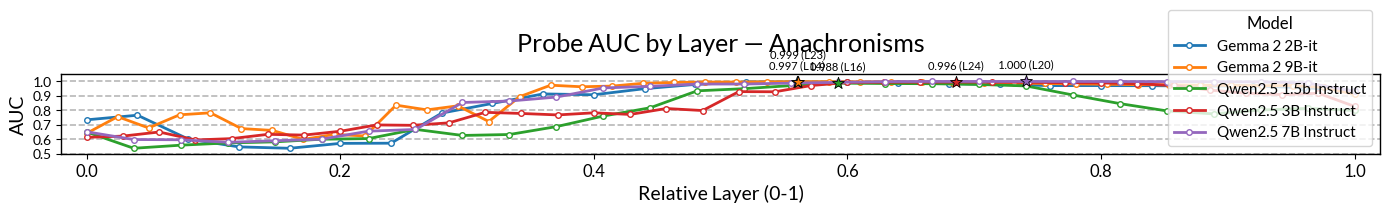

  Saved: visualizations/auc_by_layer_anachronisms.png


<Figure size 640x480 with 0 Axes>

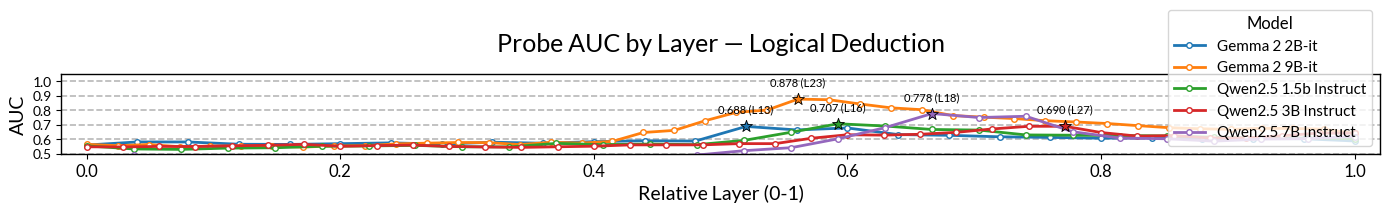

  Saved: visualizations/auc_by_layer_logical_deduction.png


<Figure size 640x480 with 0 Axes>

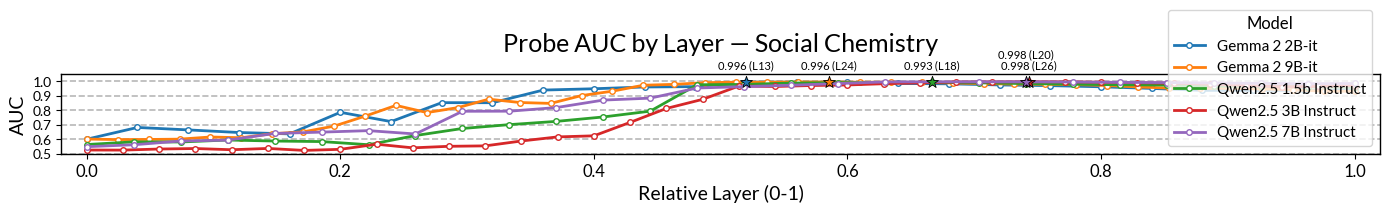

  Saved: visualizations/auc_by_layer_social_chemistry.png


<Figure size 640x480 with 0 Axes>

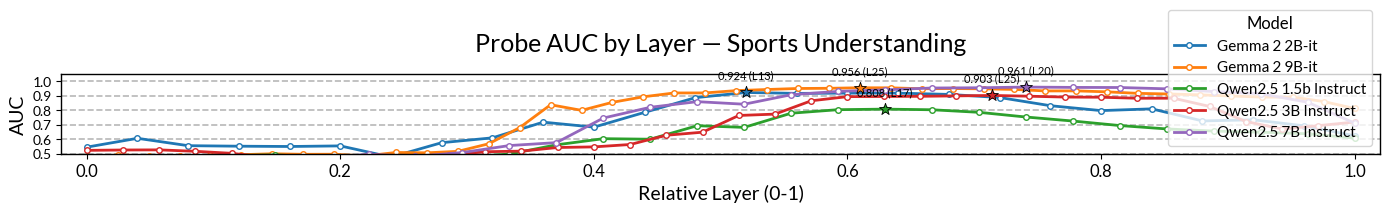

  Saved: visualizations/auc_by_layer_sports_understanding.png


<Figure size 640x480 with 0 Axes>

In [ ]:

# AUC by Layer per Dataset (separate plots)

def _format_model_label(short_name: str) -> str:
    if short_name == 'gemma-2-2b-it':
        return 'Gemma 2 2B-it'
    if short_name == 'gemma-2-9b-it':
        return 'Gemma 2 9B-it'
    return short_name.replace('-', ' ')

print('\nGenerating per-dataset AUC-by-layer plots...')
output_dir = Path('visualizations')
output_dir.mkdir(exist_ok=True)

# Use a stable palette across models
palette = sns.color_palette('tab10', n_colors=len(MODELS))

for dataset in DATASETS:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    plotted_any = False
    # Track vertical stacking offsets for labels at similar x positions to avoid overlap
    from collections import defaultdict
    label_offsets_by_x = defaultdict(int)

    for idx, model in enumerate(MODELS):
        scores = load_auc_scores(model, dataset)
        if not scores:
            continue
        label = _format_model_label(model.split('/')[-1])

        # Handle list or dict formats
        x_vals = []
        y_vals = []
        if isinstance(scores, list) and len(scores) > 0:
            x_vals = list(range(len(scores)))
            y_vals = scores
        elif isinstance(scores, dict):
            layer_pairs = []
            for k, v in scores.items():
                if isinstance(k, str) and k.startswith('layer_'):
                    try:
                        layer_idx = int(k.replace('layer_', ''))
                        layer_pairs.append((layer_idx, v))
                    except Exception:
                        continue
            if layer_pairs:
                layer_pairs.sort(key=lambda t: t[0])
                x_vals = [p[0] for p in layer_pairs]
                y_vals = [p[1] for p in layer_pairs]

        if x_vals and y_vals:
            # Normalize x to [0, 1] as layer_index / max_layer_index
            max_index = max(x_vals)
            denom = max_index if max_index > 0 else 1
            norm_x = [x / denom for x in x_vals]

            color = palette[idx % len(palette)]
            # Discrete points connected by lines (not a smooth curve)
            ax.plot(
                norm_x,
                y_vals,
                label=label,
                color=color,
                linewidth=2,
                marker='o',
                markersize=4,
                markerfacecolor='white',
                markeredgecolor=color,
            )
            # Mark best AUC point with a star and annotate above in black
            best_i = int(np.argmax(y_vals))
            best_layer = x_vals[best_i]
            best_auc = y_vals[best_i]
            ax.scatter([norm_x[best_i]], [best_auc], color=color, s=80, zorder=4, marker='*',
                       edgecolors='black', linewidths=0.6)
            # Use small vertical stacking offset to reduce overlap when x positions coincide
            key = round(norm_x[best_i], 2)
            stacked_offset = label_offsets_by_x[key]
            label_offsets_by_x[key] += 1
            ax.annotate(
                f'{best_auc:.3f} (L{best_layer})',
                xy=(norm_x[best_i], best_auc),
                xytext=(0, 8 + 8 * stacked_offset),
                textcoords='offset points',
                fontsize=8,
                fontfamily='Lato',
                color='black',
                ha='center',
                va='bottom',
            )
            plotted_any = True

    # Skip saving if nothing plotted
    if not plotted_any:
        plt.close(fig)
        print(f'  No AUC data for dataset: {dataset}')
        continue

    # Formatting
    ds_title = dataset.replace('_', ' ').title()
    if ds_title == 'Sports Understanding':
        ds_title = 'Sports Understanding'
    elif ds_title == 'Social Chemistry':
        ds_title = 'Social Chemistry'
    elif ds_title == 'Logical Deduction':
        ds_title = 'Logical Deduction'

    ax.set_title(f'Probe AUC by Layer — {ds_title}', fontsize=18, color='black', pad=16)
    ax.set_xlabel('Relative Layer (0-1)', fontsize=14, color='black')
    ax.set_ylabel('AUC', fontsize=14, color='black')

    # Normalize x-axis ticks to 0..1
    ax.set_xlim(-0.02, 1.02)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f'{t:.1f}' for t in np.linspace(0, 1, 6)], fontsize=12, color='black')

    # Y range and grid (match steering plot style)
    ax.set_ylim(0.5, 1.05)
    ax.set_yticks(np.arange(0.5, 1.05, 0.1))
    ax.grid(True, axis='y', alpha=0.6, linestyle='--', linewidth=1.2, color='#888888')
    ax.set_axisbelow(True)

    # Legend
    ax.legend(title='Model', fontsize=11, title_fontsize=12, frameon=True, loc='lower right')

    # Spines (visible black borders)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_linewidth(1.0)
    ax.spines['right'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

    plt.tight_layout()
    save_path = output_dir / f'auc_by_layer_{dataset}.png'
    plt.show()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'  Saved: {save_path}')



Generating stacked per-dataset AUC-by-layer figure...


/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2137254713.py:117: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Lato.
  plt.tight_layout()
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_2742/2137254713.py:119: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Lato.
  plt.savefig(stacked_path, dpi=300, bbox_inches='tight', facecolor='white')
.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Lato.
  fig.canvas.print_figure(bytes_io, **kw)


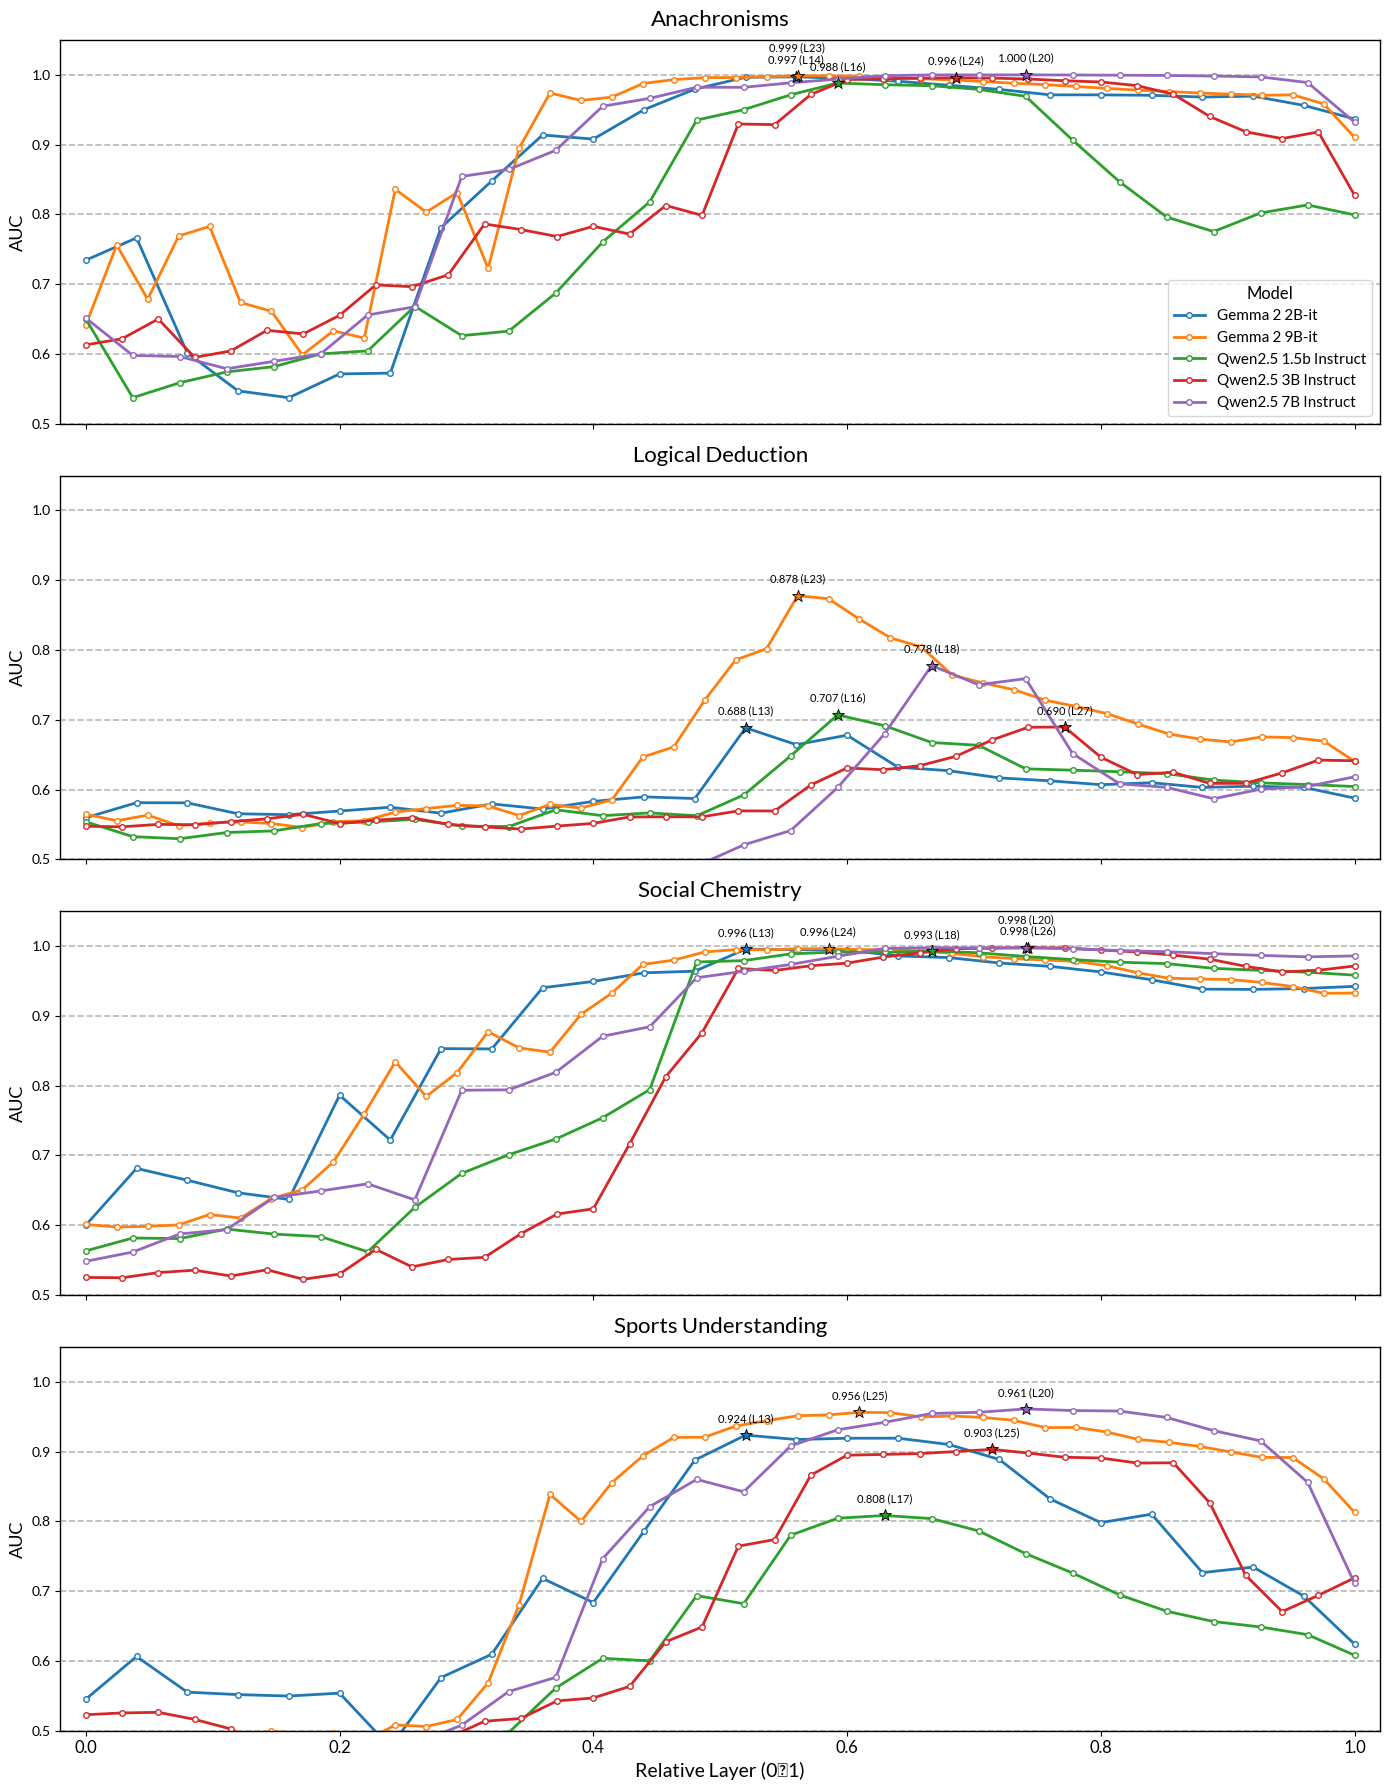

  Saved stacked figure: visualizations/auc_by_layer_stacked.png


In [69]:
# Stacked figure: AUC by Layer per Dataset (4 subplots, vertical)
print('\nGenerating stacked per-dataset AUC-by-layer figure...')
output_dir = Path('visualizations')
output_dir.mkdir(exist_ok=True)

n_rows = len(DATASETS)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 18), sharex=True)
if n_rows == 1:
    axes = [axes]

palette = sns.color_palette('tab10', n_colors=len(MODELS))

for ax, dataset in zip(axes, DATASETS):
    plotted_any = False
    from collections import defaultdict
    label_offsets_by_x = defaultdict(int)

    for idx, model in enumerate(MODELS):
        scores = load_auc_scores(model, dataset)
        if not scores:
            continue
        label = _format_model_label(model.split('/')[-1])

        x_vals = []
        y_vals = []
        if isinstance(scores, list) and len(scores) > 0:
            x_vals = list(range(len(scores)))
            y_vals = scores
        elif isinstance(scores, dict):
            layer_pairs = []
            for k, v in scores.items():
                if isinstance(k, str) and k.startswith('layer_'):
                    try:
                        layer_idx = int(k.replace('layer_', ''))
                        layer_pairs.append((layer_idx, v))
                    except Exception:
                        continue
            if layer_pairs:
                layer_pairs.sort(key=lambda t: t[0])
                x_vals = [p[0] for p in layer_pairs]
                y_vals = [p[1] for p in layer_pairs]

        if x_vals and y_vals:
            max_index = max(x_vals)
            denom = max_index if max_index > 0 else 1
            norm_x = [x / denom for x in x_vals]

            color = palette[idx % len(palette)]
            ax.plot(
                norm_x,
                y_vals,
                label=label,
                color=color,
                linewidth=2,
                marker='o',
                markersize=4,
                markerfacecolor='white',
                markeredgecolor=color,
            )

            best_i = int(np.argmax(y_vals))
            best_layer = x_vals[best_i]
            best_auc = y_vals[best_i]
            ax.scatter([norm_x[best_i]], [best_auc], color=color, s=80, zorder=4, marker='*',
                       edgecolors='black', linewidths=0.6)

            key = round(norm_x[best_i], 2)
            stacked_offset = label_offsets_by_x[key]
            label_offsets_by_x[key] += 1
            ax.annotate(
                f'{best_auc:.3f} (L{best_layer})',
                xy=(norm_x[best_i], best_auc),
                xytext=(0, 8 + 8 * stacked_offset),
                textcoords='offset points',
                fontsize=8,
                fontfamily='Lato',
                color='black',
                ha='center',
                va='bottom',
            )
            plotted_any = True

    ds_title = dataset.replace('_', ' ').title()
    if ds_title == 'Sports Understanding':
        ds_title = 'Sports Understanding'
    elif ds_title == 'Social Chemistry':
        ds_title = 'Social Chemistry'
    elif ds_title == 'Logical Deduction':
        ds_title = 'Logical Deduction'

    ax.set_title(ds_title, fontsize=16, color='black', pad=10)
    ax.set_ylabel('AUC', fontsize=13, color='black')

    ax.set_ylim(0.5, 1.05)
    ax.set_yticks(np.arange(0.5, 1.05, 0.1))
    ax.grid(True, axis='y', alpha=0.6, linestyle='--', linewidth=1.2, color='#888888')
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    for side in ['top','right','bottom','left']:
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.0)

# Shared x-axis labeling and ticks
axes[-1].set_xlabel('Relative Layer (0→1)', fontsize=14, color='black')
for ax in axes:
    ax.set_xlim(-0.02, 1.02)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f'{t:.1f}' for t in np.linspace(0, 1, 6)], fontsize=12, color='black')

# Put a legend on the top subplot (covers all curves)
axes[0].legend(title='Model', fontsize=11, title_fontsize=12, frameon=True, loc='lower right')

plt.tight_layout()
stacked_path = output_dir / 'auc_by_layer_stacked.png'
plt.savefig(stacked_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'  Saved stacked figure: {stacked_path}')


In [55]:
# Summary tables: Top AUC per model-dataset and Test Accuracy per model-dataset
from pathlib import Path

print("\nBuilding summary tables (Top AUC and Test Accuracy)...")

sheets_dir = Path("results/sheets")
sheets_dir.mkdir(parents=True, exist_ok=True)

# --- Top AUC table ---
try:
    auc_source = auc_df.copy()
except NameError:
    # Fallback: rebuild auc_df if not present
    auc_rows = []
    for model in MODELS:
        for dataset in DATASETS:
            auc_scores = load_auc_scores(model, dataset)
            if auc_scores:
                if isinstance(auc_scores, list) and len(auc_scores) > 0:
                    best_auc = max(auc_scores)
                elif isinstance(auc_scores, dict):
                    layer_scores = {k: v for k, v in auc_scores.items() if isinstance(k, str) and k.startswith('layer_')}
                    best_auc = max(layer_scores.values()) if layer_scores else None
                else:
                    best_auc = None
                if best_auc is not None:
                    auc_rows.append({
                        'Model_Short': model.split('/')[-1],
                        'Dataset': dataset,
                        'Best_AUC': best_auc,
                    })
    auc_source = pd.DataFrame(auc_rows)

if not auc_source.empty:
    auc_source['Model_Display'] = auc_source['Model_Short'].apply(_format_model_label)
    auc_table = auc_source.pivot(index='Model_Display', columns='Dataset', values='Best_AUC').sort_index()
    auc_table = auc_table.round(3)
    print("\nTop AUC by Model x Dataset (rounded to 3 decimals):")
    print(auc_table.to_string())
    auc_path = sheets_dir / 'auc_top_table.csv'
    auc_table.to_csv(auc_path)
    print(f"Saved: {auc_path}")
else:
    print("No AUC data available to build the table.")

# --- Test Accuracy table ---
acc_rows = []
for model in MODELS:
    for dataset in DATASETS:
        accs = load_generation_accuracy(model, dataset)
        if accs and accs.get('test') is not None:
            acc_rows.append({
                'Model_Display': _format_model_label(model.split('/')[-1]),
                'Dataset': dataset,
                'Test_Accuracy': round(accs['test'], 3),
            })

if acc_rows:
    acc_df = pd.DataFrame(acc_rows)
    acc_table = acc_df.pivot(index='Model_Display', columns='Dataset', values='Test_Accuracy').sort_index()
    acc_path = sheets_dir / 'test_accuracy_table.csv'
    print("\nTest Accuracy (Test %) by Model x Dataset (rounded to 3 decimals):")
    print(acc_table.to_string())
    acc_table.to_csv(acc_path)
    print(f"Saved: {acc_path}")
else:
    print("No test accuracy data available to build the table.")



Building summary tables (Top AUC and Test Accuracy)...

Top AUC by Model x Dataset (rounded to 3 decimals):
Dataset                anachronisms  logical_deduction  social_chemistry  sports_understanding
Model_Display                                                                                 
Gemma 2 2B-it                 0.997              0.688             0.996                 0.924
Gemma 2 9B-it                 0.999              0.878             0.996                 0.956
Qwen2.5 1.5b Instruct         0.988              0.707             0.993                 0.808
Qwen2.5 3B Instruct           0.996              0.690             0.998                 0.903
Qwen2.5 7B Instruct           1.000              0.778             0.998                 0.961
Saved: results/sheets/auc_top_table.csv

Test Accuracy (Test %) by Model x Dataset (rounded to 3 decimals):
Dataset                anachronisms  logical_deduction  social_chemistry  sports_understanding
Model_Display          